In [1]:
import pandas as pd 
pd.set_option('display.max_colwidth', None)

import numpy as np
from collections import Counter


# Merging 2 data frame

In [2]:
# import pandas as pd

# # Load training data
# df_train = pd.read_excel("Usable_preprocessed_ArkStone.xlsx")
# df_train.columns = df_train.columns.str.lower()
# del df_train["removed entries"]

# # Load test data
# df_test = pd.read_excel("Usable_preprocessed_ArkStone_test.xlsx")
# df_test.columns = df_test.columns.str.lower()


# # Columns in df_train but not in df_test
# print("In train but not in test:", df_train.columns.difference(df_test.columns))

# # Columns in df_test but not in df_train
# print("In test but not in train:", df_test.columns.difference(df_train.columns))


# print("train shape :",df_train.shape)
# print("test shape :",df_test.shape)
# print("Total :",df_train.shape[0] + df_test.shape[0])
# # Merge the two DataFrames
# df_merged = pd.concat([df_train, df_test], ignore_index=True)
# # df_merged = df_train.copy()

# # Optional: check result
# print("Merged shape:", df_merged.shape)

In [3]:
# df_merged.to_excel("merged.xlsx",index=False)

# import merged

In [180]:
df_merged = pd.read_excel("merged.xlsx")

all_columns  = list(df_merged.columns)

features = pd.read_csv("train_features.csv")
features_list = features.to_numpy().flatten().tolist()
targets = pd.read_csv("train_target.csv")
target_list = targets.to_numpy().flatten().tolist()


### Oragnism column

In [181]:
df_merged["organism detected"] = df_merged["organism detected"].fillna("none detected").str.lower()

In [182]:
# Clean the "organism detected" column by removing empty/whitespace parts

df_merged["organism detected"] = df_merged["organism detected"].apply(
    lambda x: '\n'.join([part.strip() for part in str(x).split('\n') if part.strip()])
)

In [183]:
organism_names = list(Counter(df_merged["organism detected"].str.split("\n").explode().str.strip()))

In [184]:
Counter(df_merged["organism detected"].str.split("\n").explode().str.strip())

Counter({'escherichia coli': 3922,
         'anaerococcus spp': 2111,
         'enterococcus spp': 1910,
         'klebsiella pneumoniae': 1231,
         'enterococcus faecalis': 905,
         'streptococcus agalactiae': 743,
         'pseudomonas aeruginosa': 611,
         'proteus spp': 570,
         'enterobacter cloacae': 518,
         'candida glabrata': 466,
         'proteus mirabilis': 445,
         'klebsiella oxytoca': 410,
         'candida spp': 280,
         'morganella morganii': 252,
         'citrobacter spp': 243,
         'aerococcus urinae': 240,
         'staphylococcus saprophyticus': 141,
         'klebsiella aerogenes': 99,
         'staphylococcus aureus': 68,
         'acinetobacter baumannii': 66,
         'candida albicans': 59,
         'enterobacter aerogenes': 57,
         'providencia stuartii': 56,
         'enterococcus faecium': 54,
         'candida krusei': 47,
         'mycoplasma genitalium': 42,
         'none detected': 36,
         'corynebacter

#### oranism name dictionary

In [185]:
# from collections import Counter

# diff = set(df_merged["organism detected"].str.split("\n").explode().str.strip().str.lower().unique()) - set(organism_name_dict.keys())


In [186]:
organism_name_dict = {
    "escherichia coli": {"escherichia coli", "e. coli", "e coli", "Escherichia coli"},
    "anaerococcus spp": {"anaerococcus spp", "Anaerococcus spp", "anaerococcus"},
    "enterococcus spp": {"enterococcus spp", "Enterococcus spp", "enterococcus"},
    "klebsiella pneumoniae": {"klebsiella pneumoniae", "Klebsiella pneumoniae"},
    "enterococcus faecalis": {"enterococcus faecalis", "Enterococcus faecalis"},
    "streptococcus agalactiae": {"streptococcus agalactiae", "Streptococcus agalactiae"},
    "pseudomonas aeruginosa": {"pseudomonas aeruginosa", "Pseudomonas aeruginosa"},
    "proteus spp": {"proteus spp", "Proteus spp", "proteus"},
    "enterobacter cloacae": {"enterobacter cloacae", "Enterobacter cloacae"},
    "candida glabrata": {"candida glabrata", "Candida glabrata"},
    "proteus mirabilis": {"proteus mirabilis", "Proteus mirabilis"},
    "klebsiella oxytoca": {"klebsiella oxytoca", "Klebsiella oxytoca"},
    "candida spp": {"candida spp", "Candida spp", "candida"},
    "morganella morganii": {"morganella morganii", "Morganella morganii"},
    "citrobacter spp": {"citrobacter spp", "Citrobacter spp", "citrobacter"},
    "aerococcus urinae": {"aerococcus urinae", "Aerococcus urinae"},
    "staphylococcus saprophyticus": {"staphylococcus saprophyticus", "Staphylococcus saprophyticus"},
    "klebsiella aerogenes": {"klebsiella aerogenes", "Klebsiella aerogenes"},
    "staphylococcus aureus": {"staphylococcus aureus", "Staphylococcus aureus"},
    "acinetobacter baumannii": {"acinetobacter baumannii", "Acinetobacter baumannii"},
    "candida albicans": {"candida albicans", "Candida albicans"},
    "enterobacter aerogenes": {"enterobacter aerogenes", "Enterobacter aerogenes"},
    "providencia stuartii": {"providencia stuartii", "Providencia stuartii"},
    "enterococcus faecium": {"enterococcus faecium", "Enterococcus faecium"},
    "candida krusei": {"candida krusei", "Candida krusei"},
    "mycoplasma genitalium": {"mycoplasma genitalium", "Mycoplasma genitalium"},
    "corynebacterium riegelii": {"corynebacterium riegelii", "Corynebacterium riegelii"},
    "none detected": {"none detected", "None detected", "none"},
    "citrobacter koseri": {"citrobacter koseri", "Citrobacter koseri"},
    "chlamydia trachomatis": {"chlamydia trachomatis", "Chlamydia trachomatis"},
    "neisseria gonorrhoea": {"neisseria gonorrhoea", "Neisseria gonorrhoea"},
    "streptococcus pasteuranus": {"streptococcus pasteuranus", "Streptococcus pasteuranus"},
    "streptococcus oralis": {"streptococcus oralis", "Streptococcus oralis"},
    "staphylococcus epidermidis": {"staphylococcus epidermidis", "Staphylococcus epidermidis"},
    "citrobacter amalonaticus": {"citrobacter amalonaticus", "Citrobacter amalonaticus"},
    "trichomonas vaginalis": {"trichomonas vaginalis", "Trichomonas vaginalis"},
    "staphylococcus haemolyticus": {"staphylococcus haemolyticus", "Staphylococcus haemolyticus"},
    "serratia marcescens": {"serratia marcescens", "Serratia marcescens"},
    "staphylococcus lugdunensis": {"staphylococcus lugdunensis", "Staphylococcus lugdunensis"},
    "candida parapsilosis": {"candida parapsilosis", "Candida parapsilosis"},
    "neisseria gonorrhoeae": {"neisseria gonorrhoeae", "Neisseria gonorrhoeae"},
    "pantoea agglomerans": {"pantoea agglomerans", "Pantoea agglomerans"},
    "corynebacterium urealyticum": {"corynebacterium urealyticum", "Corynebacterium urealyticum"},
    "ureaplasma urealyticum": {"ureaplasma urealyticum", "Ureaplasma urealyticum"},
    "proteus vulgaris": {"proteus vulgaris", "Proteus vulgaris"},
}

### resistence detected 


In [ ]:
# Fill NaNs
df_merged["resistance detected"] = df_merged["resistance detected"].fillna("none detected")

df_merged["resistance detected"] = df_merged["resistance detected"].str.replace(", ",",",regex=False)

df_merged["resistance detected"] = df_merged["resistance detected"].str.replace(",","\n",regex=False)

# Clean the 'resistance detected' column by stripping extra spaces and then split
df_merged["resistance detected"] = df_merged["resistance detected"].str.split("\n").apply(lambda x: [i.strip() for i in x])

# You can also check the cleaned column to confirm
print(df_merged["resistance detected"].head())


In [189]:
resistance_names = list(Counter(df_merged["resistance detected"].explode()))

In [190]:
Counter(df_merged["resistance detected"].explode())

Counter({'macrolide/clindamycin': 3086,
         'tmp-smx': 2460,
         'tetracycline': 2100,
         'macrolide': 2081,
         'methicillin': 1709,
         'none detected': 1242,
         'beta-lactam': 454,
         'quinolone': 446,
         'extended-spectrum beta-lactamase': 280,
         'vancomycin': 101,
         'carbapenem': 76,
         'ampicillin/cephalosporin': 13})

### resistance name dictionary

In [191]:
resistance_name_dict = {
    "macrolide/clindamycin": {"macrolide/clindamycin", "Macrolide/Clindamycin", "macrolide + clindamycin"},
    "tetracycline": {"tetracycline", "Tetracycline"},
    "tmp-smx": {"tmp-smx", "TMP-SMX", "tmp/smx", "tmp smx", "trimethoprim-sulfamethoxazole","trimethoprimsulfamethoxazole","tmpsmx"},
    "macrolide": {"macrolide", "Macrolide"},
    # "none detected": {"none detected", "None detected", "no resistance","none","no"},
    "methicillin": {"methicillin", "Methicillin"},
    "beta-lactam": {"beta-lactam", "Beta-lactam", "β-lactam", "beta lactam"},
    "quinolone": {"quinolone", "Quinolone", "fluoroquinolone", "quinolones"},
    "extended-spectrumbeta-lactamase": {
        "extended-spectrumbeta-lactamase",
        "Extended-spectrum beta-lactamase",
        "esbl",
        "ESBL",
        "extended spectrum beta lactamase"
    },
    "vancomycin": {"vancomycin", "Vancomycin"},
    "carbapenem": {"carbapenem", "Carbapenem", "carbapenems"},
    "ampicillin/cephalosporin": {"ampicillin/cephalosporin", "Ampicillin/Cephalosporin", "ampicillin + cephalosporin"},
}

## Primary Drug

#### drug name dict

In [192]:
drug_name_dict = {
    "Fosfomycin": [
        "Fosfomycin", "Fosfomycin°", "Fosfomycin’", "Fosfomycin3", "F0sfomycin°"
    ],
    "Amox/Clav": [
        "Amox/Clav", "Amox/Clav°", "Amox/Clav`", "AMOx/Clav°", "AmOx/Clav", 
        "Amox-clav", "Amoxicillin-clavulanate"
    ],
    "Macrobid": [
        "Macrobid", "Macrobid°", "Macrobid°100","Macro"
    ],
    "Ciprofloxacin": [
        "Cipro", "Cipro°", "CIPRO","Ciprofloxacin"
    ],
    "Cephalexin": [
        "Cephalexin", "Cephalexin°", "cephalexin"
    ],
    "Levofloxacin": [
        "Levofloxacin", "Levofloxacin°", "Levofloxacin250-750", "levofloxacin", 
        "evofloxacin"
    ],
    "Linezolid": [
        "Linezolid", "Linezolid250-750", "Linezolid500", "linezolid"
    ],
    "Gentamicin": [
        "Gentamicin", "Gentamicin°", "Gentami"
    ],
    "Vancomycin": [
        "Vancomycin", "°Vancomycin", "hVancomycin"
    ],
    "Cefepime": [
        "Cefepime", "Cefepime°", "Cefepime1-2"
    ],
    "Amoxicillin": [
        "Amoxicillin", "Amoxicillin°", "moxicillin°"
    ],
    "Pip/Taz": [
        "Pip/Taz", "Pip/Taz°", "°Pip/Taz", "Piperacillin/tazobactam"
    ],
    "trimethoprimsulfamethoxazole": [
        "TMP-SMX", "TMP-SMX°", "TMP-SMXDS", "°TMP-SMX", "TMP-", "TMP", 
        "trimethoprimsulfamethoxazole",
        "Trimethoprim-Sulfamethoxazole"
    ],
    "Flucytosine": [
        "Flucytosine", "Flucytosine°", "Fucytosine°", "lucytosine"
    ],
    "Ceftriaxone": ["Ceftriaxone"],
    "Ertapenem": ["Ertapenem", "Ertapenem°"],
    "Meropenem": ["Meropenem", "Meropenem°", "meropenem"],
    "Daptomycin": ["Daptomycin"],
    "Cefixime": ["Cefixime", "Cefixime°"],
    "Cefiderocol": ["Cefiderocol", "Cefiderocol°", "Cefideroco"],
    "Ceftazidime": ["Ceftazidime", "Cefiazidime"],
    "Azithromycin": ["Azithromycin", "azithromycin"],
    "Doxycycline": ["Doxycycline", "Doxycycline°"],
    "Metronidazole": ["Metronidazole"],
    "Tinidazole": ["Tinidazole"],
    "Moxifloxacin": ["Moxifloxacin", "Moxifloxac"],
    "Amikacin": ["Amikacin°","Amikacin"],
    "Ampicillin": ["Ampicillin", "ampicillin"],
    "AMP/SUL": ["AMP/SUL", "AMP/SUL°", "AMP/Sul"]
}


In [193]:
# df_merged["one choice drug info"] = df_merged["one choice drug info"].str.lower()

In [194]:

import re
import pandas as pd

# Build a mapping of all variants to their canonical names
variant_to_canonical = {}
for canonical, variants in drug_name_dict.items():
    for name in variants:
        variant_to_canonical[name.lower()] = canonical.lower()

def extract_alternate_drugs(text, variant_map):
    if pd.isna(text):
        return ''

    # found = set()
    # text_str = str(text).lower()
    found = []  # Ensure this is a list to preserve order
    text_str = str(text).lower()

    # Normalize text and find known drug variants
    for match in re.finditer(r'\b[\w/-]+\b', text_str):
        word = match.group(0)
        # if word in variant_map:
                    # found.add(variant_map[word])
        # To maintain the order from the original text
        if word in variant_map and variant_map[word] not in found: 
            found.append(variant_map[word])
    # return ', '.join(sorted(found))  # sorted for consistent order
    return ', '.join(found)  # No sorting


# Apply to your column
df_merged["primary_drug"] = df_merged["one choice drug info"].apply(
    lambda x: extract_alternate_drugs(x, variant_to_canonical)
)



In [195]:
df_merged[df_merged["accession id."]=="DU240429010"]["one choice drug info"]

5628    Amoxicillin 500 mg PO TID x 5 days (minimum) with TrimethoprimSulfamethoxazole DS 1 tab PO BID x 3 days for possible simple UTI
Name: one choice drug info, dtype: object

In [196]:
[print(i) for i in df_merged[df_merged["primary_drug"].isin([''])]["one choice drug info"].value_counts().index]

not be indicated
Not Applicable
Treatment may not be indicated
NILL
none
See below regarding treatment recommendations
 not be indicated
Treatment may not be indicated (see below regarding
Staph saprophyticus)
Treatment may not be indicated (see below regarding Staph saprophyticus)


[None, None, None, None, None, None, None, None, None]

In [197]:
# put NOt applicable in empty columns
df_merged.loc[df_merged["primary_drug"].isin(['']), "primary_drug"] = "not applicable"


In [198]:
df_merged["primary_drug"] = df_merged["primary_drug"].str.strip()

In [199]:
Counter(df_merged["primary_drug"].explode())

Counter({'macrobid': 2231,
         'trimethoprimsulfamethoxazole': 2014,
         'amoxicillin': 1000,
         'fosfomycin': 589,
         'not applicable': 466,
         'levofloxacin': 252,
         'ciprofloxacin': 179,
         'levofloxacin, macrobid': 91,
         'linezolid': 78,
         'cephalexin': 64,
         'macrobid, amoxicillin': 41,
         'trimethoprimsulfamethoxazole, amoxicillin': 23,
         'doxycycline': 20,
         'doxycycline, moxifloxacin': 17,
         'ceftriaxone': 16,
         'macrobid, levofloxacin': 16,
         'ciprofloxacin, macrobid': 15,
         'fosfomycin, amoxicillin': 14,
         'macrobid, ciprofloxacin': 13,
         'metronidazole': 12,
         'amox/clav': 11,
         'pip/taz': 10,
         'ampicillin': 9,
         'doxycycline, azithromycin': 9,
         'gentamicin': 8,
         'amoxicillin, macrobid': 6,
         'fosfomycin, trimethoprimsulfamethoxazole': 5,
         'trimethoprimsulfamethoxazole, linezolid': 5,
         

In [200]:
# df_merged["primary_drug"].value_counts()

### Ark Score

In [201]:
unique_drugs = Counter(df_merged["primary_drug"].str.split(",").explode().str.strip().explode()).keys()
unique_drugs = list(unique_drugs)

In [202]:
df_merged[(df_merged["primary_drug"] == "trimethoprimsulfamethoxazole") &(df_merged["adverse reaction arkscore"]==3)]

,s.no.,accession id.,organism detected,ct mean,resistance detected,resistance ct mean,antimicrobial resistance arkscore,adverse reaction arkscore,infection complexity arkscore,dosing adj,...,alternative treatment options,drug name.1,concentration.1,dosage per day.1,duration.1,ark score,why is this the onechoice?,when should this be treated?,are there any special considerations?,primary_drug
3519,3319,MU240625021,escherichia coli\nanaerococcus spp,25.11\n25.59,"[tmp-smx, macrolide, macrolide/clindamycin, methicillin]",20.56 \n22.60 \n26.61\n34.66,7,3,4,renal,...,Fosfomycin pediatric dosed x undefined duration\nAmox/Clav pediatric dosed x undefined duration\nCephalexin° pediatric dosed x 7-14 days\nLevofloxacin pediatric dosed with caution x 7-14 days,Fosfomycin pediatric dosed x undefined duration\nAmox/Clav pediatric dosed x undefined duration\nCephalexin° undef°atric dosed -14 days\nLevofloxacin pe,3 inhoshech undeh,amhMacrolide\nMacrolidehMacrolide\nMacrolidehiatriiatric dosed wit,NaN,1\n2\n1\n5,"E. coli can be pathogenic when found in urine samples. Anaerococcus was not targeted since it may be a colonizer, found naturally, or a possible contaminant. If concerned, treatment modifications may be needed. Resistance genes were detected in multiple classes, of which TMP-SMX resistance may limit available treatment options. Pediatric patients may require dose and duration adjustments. Macrobid efficacy against E. coli is uncertain. ‡","Children with upper UTIs or pyelonephritis may present with dysuria, polyuria, fever, and flank pain. Hematuria is also possible. Asymptomatic bacteriuria should generally not be treated in children. E. coli is the most common pathogen causing UTIs in children. Recurrent UTIs in children may warrant further workup such as renal ultrasound. Although treatment is typically for 7-14 days, there is data to suggest shorter therapy such as 2-4 days may be equally effective.","Anaerococcus can be part of normal urogenital flora but may be pathogenic in certain scenarios. If concerned, treatment modification may be required. A positive specimen does not always imply infection. Resistance is variable; therefore, drug failure is possible. Resistance detected may only affect certain microbes, and in some cases, none at all. ‡",trimethoprimsulfamethoxazole
5220,5094,MU240627034,klebsiella oxytoca\nenterococcus spp,15.18\n17.91,"[tmp-smx, extended-spectrum beta-lactamase, macrolide, macrolide/clindamycin]",14.15\n13.52\n22.40\n29.07,7,3,5,Renal,...,Fosfomycin° 3 gm PO x 1 dose\n\nLevofloxacin 250-750 mg PO daily x 3 days with Linezolid dose not defined x undefined duration\n\nAmoxicillin 500 mg PO TID x 5 days (minimum) \n\nGentamicin° 5 mg/kg IV/IM x 1 dose\n\n\n,NaN,NaN,Pecclnx,1 dose3 rolin 1 dose,"1\n5,4,1\n5","Enterococcus species and Klebsiella oxytoca can be pathogenic when found in\nurine samples with a suspected diagnosis of UTI. Resistance genes were detected in\nmultiple classes, of which TMP-SMX and ESBL resistance may limit available\ntreatment options. ‡","Asymptomatic bacteriuria does not typically need treatment, and microbe detection\nmay not indicate infection. However, treatment may be necessary during pregnancy\nor prior to urological procedures. Simple UTIs are typically treated for 3 days\n(fluoroquinolones/TMP-SMX), or 5 days (beta-lactams). In more complicated cases\ntherapy may be extended to 7-14 days. STI treatment is specific to the microbe\nbeing treated and antimicrobial being used. ‡","Enterococcus species may have intrinsic resistance to certain antimicrobials, making\nit difficult to treat. Enterococcus species may require modified dosing and duration.\nAs ESBL resistance is on the CDC threat list, tracking and monitoring may be\nindicated if possible. ESBL can be associated with other resistance genes.\nAntibiotics should therefore be used with caution as drug failure is possible.\nResistance detected may only affect certain microbes, and in some cases, none at\nall. ‡",trimet

In [203]:
# df_merged[df_merged["primary_drug"] == "moxifloxacin"]["adverse reaction arkscore"].value_counts().index[0]
df_merged[df_merged["primary_drug"] == "moxifloxacin"]["adverse reaction arkscore"].value_counts()

Series([], Name: count, dtype: int64)

In [204]:
for i in unique_drugs:
    values = df_merged[df_merged["primary_drug"] == i]["adverse reaction arkscore"].value_counts()
    if not values.empty:
        print(i,":",values.index[0])
    else : 
        print(i,":","-")
        

trimethoprimsulfamethoxazole : 2
macrobid : 3
fosfomycin : 1
ciprofloxacin : 5
not applicable : -
amoxicillin : 1
levofloxacin : 5
linezolid : 4
amox/clav : 2
cephalexin : 1
ampicillin : 1
metronidazole : 2
ceftriaxone : 2
pip/taz : 4
doxycycline : 2
moxifloxacin : -
azithromycin : 1
cefixime : 1
cefepime : -
vancomycin : -
gentamicin : 5
meropenem : -
amikacin : 5
ertapenem : -


In [205]:
# moxifloxacin - 5
# cefepime - 3
# vancomycin - 4 
# meropenem - 3
# ertapenem - 3
# trimethoprimsulfamethoxazole : 2
# macrobid : 3
# fosfomycin : 1
# ciprofloxacin : 5
# not applicable : -
# amoxicillin : 1
# levofloxacin : 5
# linezolid : 4
# amox/clav : 2
# cephalexin : 1
# ampicillin : 1
# metronidazole : 2
# ceftriaxone : 2
# pip/taz : 4
# doxycycline : 2
# azithromycin : 1
# cefixime : 1
# gentamicin : 5
# amikacin : 5

#### exctraction of secondary drug

In [206]:
# alternate_df = df_merged.copy()
# b = alternate_df["alternative treatment options"].str.split("\n").explode().str.strip()
# first_words = b.str.strip().str.split().str[0]
# # Counter(first_words)

## Working on Alternate drug column

### code exctract alternate drug from column and place in new

#### new_df

In [207]:
new_df = pd.read_excel("raw/new.xlsx")

# Keep only rows where "Alternative Treatment Options" contains "Macrobid"
filtered_df = new_df[new_df["Alternative Treatment Options"].str.contains("TMP-SMX", case=False, na=False)]
filtered_df = filtered_df.reset_index(drop=True)
new_df = filtered_df

In [208]:
# Drop duplicates to avoid indexing issues
lookup = new_df.drop_duplicates(subset="Accession ID.").copy()

# Create mapping dictionary
mapping_dict = lookup.set_index("Accession ID.")["Alternative Treatment Options"]

# Use mask to update only matched rows
df_merged["alternative treatment options"] = df_merged.apply(
    lambda row: mapping_dict[row["accession id."]]
    if row["accession id."] in mapping_dict else row["alternative treatment options"],
    axis=1
)


In [209]:
# Apply the function to your column which exctract the drug name 
df_merged["alternate_drug_options"] = df_merged["alternative treatment options"].apply(
    lambda x: extract_alternate_drugs(x, variant_to_canonical)
)


In [210]:
# strip the blank spaces 
df_merged["alternate_drug_options"] = df_merged["alternate_drug_options"].apply(
    lambda x: [i.strip() for i in x.split(",")] if pd.notnull(x) else []
)


In [211]:
df_merged.shape

(7245, 27)

In [212]:
df_merged["alternate_drug_options"].value_counts()

alternate_drug_options
[macrobid, cephalexin, fosfomycin, amox/clav, ciprofloxacin]                                           573
[macrobid, fosfomycin, linezolid, vancomycin]                                                          239
[amox/clav]                                                                                            216
[fosfomycin, linezolid, amoxicillin, vancomycin]                                                       162
[cephalexin, linezolid, vancomycin]                                                                    143
                                                                                                      ... 
[fosfomycin, amox/clav, trimethoprimsulfamethoxazole, linezolid, pip/taz]                                1
[trimethoprimsulfamethoxazole, linezolid, macrobid, fosfomycin, meropenem, vancomycin]                   1
[amox/clav, macrobid, linezolid, trimethoprimsulfamethoxazole, amp/sul]                                  1
[macrobid, fos

In [213]:
df_merged.shape

(7245, 27)

In [214]:
df_merged.loc[df_merged["alternate_drug_options"].apply(lambda x: "" in x), "alternate_drug_options"] = "not applicable"


In [215]:
Counter(df_merged["alternate_drug_options"].explode())

Counter({'fosfomycin': 5660,
         'macrobid': 2915,
         'linezolid': 2880,
         'amox/clav': 2629,
         'levofloxacin': 2606,
         'ciprofloxacin': 2180,
         'cephalexin': 2072,
         'amoxicillin': 1506,
         'gentamicin': 1350,
         'vancomycin': 1282,
         'trimethoprimsulfamethoxazole': 1060,
         'cefepime': 978,
         'pip/taz': 737,
         'flucytosine': 546,
         'amp/sul': 488,
         'ceftriaxone': 337,
         'ertapenem': 235,
         'meropenem': 208,
         'ceftazidime': 199,
         'daptomycin': 171,
         'cefixime': 98,
         'cefiderocol': 55,
         'not applicable': 46,
         'doxycycline': 46,
         'moxifloxacin': 42,
         'ampicillin': 14,
         'tinidazole': 13,
         'azithromycin': 12,
         'amikacin': 9,
         'metronidazole': 1})

In [216]:
df_merged.columns

Index(['s.no.', 'accession id.', 'organism detected', 'ct mean',
       'resistance detected', 'resistance ct mean',
       'antimicrobial resistance arkscore', 'adverse reaction arkscore',
       'infection complexity arkscore', 'dosing adj', 'one choice drug info',
       'drug name', 'concentration', 'dosage per day', 'duration',
       'second choice drug info', 'alternative treatment options',
       'drug name.1', 'concentration.1', 'dosage per day.1', 'duration.1',
       'ark score', 'why is this the onechoice?',
       'when should this be treated?', 'are there any special considerations?',
       'primary_drug', 'alternate_drug_options'],
      dtype='object')

In [265]:
corr_df = df_merged.copy()

In [266]:
corr_df.columns

Index(['s.no.', 'accession id.', 'organism detected', 'ct mean',
       'resistance detected', 'resistance ct mean',
       'antimicrobial resistance arkscore', 'adverse reaction arkscore',
       'infection complexity arkscore', 'dosing adj', 'one choice drug info',
       'drug name', 'concentration', 'dosage per day', 'duration',
       'second choice drug info', 'alternative treatment options',
       'drug name.1', 'concentration.1', 'dosage per day.1', 'duration.1',
       'ark score', 'why is this the onechoice?',
       'when should this be treated?', 'are there any special considerations?',
       'primary_drug', 'alternate_drug_options'],
      dtype='object')

In [269]:
corr_df = corr_df.drop(columns=['s.no.'])

In [271]:
corr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7245 entries, 0 to 7244
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   accession id.                          7245 non-null   object
 1   organism detected                      7245 non-null   object
 2   ct mean                                6960 non-null   object
 3   resistance detected                    7245 non-null   object
 4   resistance ct mean                     6359 non-null   object
 5   antimicrobial resistance arkscore      6957 non-null   object
 6   adverse reaction arkscore              6955 non-null   object
 7   infection complexity arkscore          6959 non-null   object
 8   dosing adj                             6878 non-null   object
 9   one choice drug info                   7245 non-null   object
 10  drug name                              7227 non-null   object
 11  concentration    

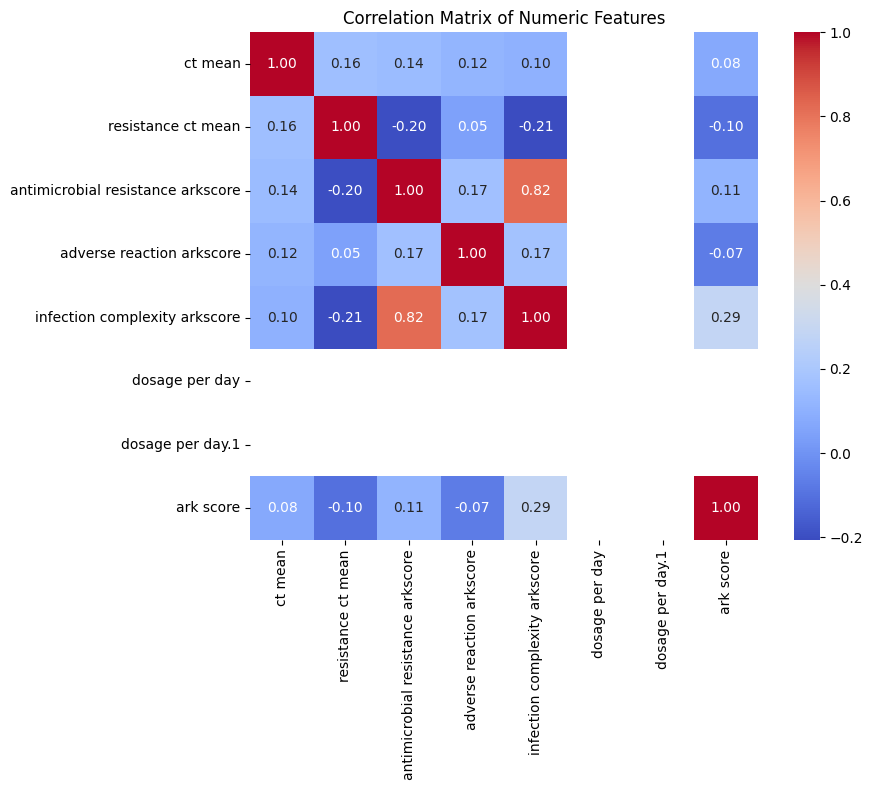

In [272]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copy DataFrame to avoid modifying original
df_numeric = corr_df.copy()

# List of object-type columns to convert to numeric
numeric_columns = [
    'ct mean',
    'resistance ct mean',
    'antimicrobial resistance arkscore',
    'adverse reaction arkscore',
    'infection complexity arkscore',
    'dosage per day',
    'dosage per day.1',
    'ark score'
]

# Convert columns to numeric (non-convertible values become NaN)
df_numeric[numeric_columns] = df_numeric[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Compute correlation matrix
correlation_matrix = df_numeric[numeric_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()


### ml_df_ct

In [275]:
ml_df_ct = df_merged[["accession id.",
                   "organism detected",'ct mean',
                   "one choice drug info",
                   "resistance detected",'resistance ct mean',
                   "primary_drug",
                    "infection complexity arkscore",
                   "alternate_drug_options",
                    'alternative treatment options']].copy()

In [ ]:
# calculate organism ct count
def count_values(x):
    if pd.isna(x) or x == "none" or x == "-" or x == "none detected":
        return 0
    elif isinstance(x, float) or isinstance(x, int):
        return 1
    else:
        return len([v for v in x.strip().split("\n") if v.strip() != ""])

# calculate organism count and ct mean
ml_df_ct["organism_detected_count"] = ml_df_ct["organism detected"].apply(count_values)

ml_df_ct["organism_ct_count"] = ml_df_ct["ct mean"].apply(count_values)

ml_df_ct = ml_df_ct[~((ml_df_ct["organism_ct_count"] == 0) &
                      (ml_df_ct["organism detected"] != "none detected"))].reset_index(drop = True)

# the organism and its ct_mean count should be equal 
ml_df_ct = ml_df_ct[ml_df_ct["organism_detected_count"] == ml_df_ct["organism_ct_count"]].reset_index(drop=True)


# calculate resistance count and ct mean

ml_df_ct["resistance_count"] = ml_df_ct["resistance detected"].apply(
    lambda x: 0 if isinstance(x, list) and x == ["none detected"] else len(x) if isinstance(x, list) else 0
)
ml_df_ct["resistance_ct_count"] = ml_df_ct["resistance ct mean"].apply(count_values)

# keep this
# if the primary drug is not applicable then drug concentration and duration is also not applicable 

ml_df_ct = ml_df_ct[~((ml_df_ct["resistance_ct_count"] != 0) & (ml_df_ct["resistance_count"] != ml_df_ct["resistance_ct_count"]))].reset_index(drop=True)


# creating organism names list as column 
for names in organism_names:
    ml_df_ct[names] = 0.0



### ct mean

In [280]:
def clean_and_store_ct_values(val):
    # If the value is already a float, store it as a list with one value
    if isinstance(val, float):
        return [val]
    # If the value is a string, try converting it
    elif isinstance(val, str):
        val = val.strip().lower()
        # If the string is "none" or empty, return an empty list
        if val == 'none' or not val:
            return []
        # Try converting the string to a list of floats
        try:
            # Handle multiple values separated by '\n'
            values = [float(x.strip()) for x in val.split('\n') if x.strip().replace('.', '', 1).isdigit()]
            return values if values else []
        except ValueError:
            return []
    return []

ml_df_ct["ct mean"] = ml_df_ct["ct mean"].apply(clean_and_store_ct_values)


In [281]:
import numpy as np

# Identify all organism columns — assuming they're between known start and end columns
organism_columns = ml_df_ct.columns[
    ml_df_ct.columns.get_loc("escherichia coli") : ml_df_ct.columns.get_loc("proteus vulgaris") + 1
]

# Forcefully convert all organism columns to float64
ml_df_ct[organism_columns] = ml_df_ct[organism_columns].apply(pd.to_numeric, errors='coerce').astype("float64")

# Now update the DataFrame row-wise
for index, row in ml_df_ct.iterrows():
    organism = row["organism detected"]
    ct_values = row["ct mean"]

    if "none detected" in organism:
        ml_df_ct.loc[index, organism_columns] = 0.0
    else:
        organisms = organism.split("\n")
        ct_values_list = ct_values if isinstance(ct_values, list) else [ct_values]

        for org, ct in zip(organisms, ct_values_list):
            org_clean = org.strip()
            if org_clean in ml_df_ct.columns:
                ml_df_ct.loc[index, org_clean] = float(ct) if ct else 0.0

# For rows with empty ct mean list, set organism columns to 0
ml_df_ct.loc[ml_df_ct["ct mean"].apply(lambda x: x == []), organism_columns] = 0.0


In [282]:
# creating resistance names list as column 
for names in resistance_names:
    ml_df_ct[names] = 0.0
ml_df_ct["resistance ct mean"] = ml_df_ct["resistance ct mean"].fillna("none")
ml_df_ct["resistance ct mean"] = ml_df_ct["resistance ct mean"].apply(clean_and_store_ct_values)

In [283]:
ml_df_ct[["resistance detected","resistance ct mean"]+organism_names+resistance_names]

,resistance detected,resistance ct mean,escherichia coli,enterococcus faecalis,klebsiella pneumoniae,enterobacter cloacae,proteus mirabilis,citrobacter koseri,klebsiella oxytoca,candida glabrata,...,beta-lactam,tetracycline,vancomycin,macrolide/clindamycin,quinolone,methicillin,ampicillin/cephalosporin,carbapenem,macrolide,extended-spectrum beta-lactamase
0,[none detected],[],16.78,0.00,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,[tmp-smx],[22.99],22.70,0.00,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"[beta-lactam, tetracycline, tmp-smx, vancomycin]","[17.22, 22.66, 20.45, 26.9]",23.85,23.57,17.32,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"[beta-lactam, macrolide/clindamycin, tetracycline, tmp-smx]","[23.04, 21.58, 20.42, 20.78]",22.38,20.44,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"[macrolide/clindamycin, tetracycline]","[24.03, 23.61]",0.00,20.52,23.99,20.82,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5444,[none detected],[],0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5445,[none detected],[],0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5446,[none detected],[],0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5447,[tmp-smx],[],0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [284]:
# fill ct mean with for resistance columns
# First, make sure all resistance columns are float type to avoid dtype warnings
ml_df_ct[resistance_names] = ml_df_ct[resistance_names].astype('float64')

# Loop through each row to populate resistance CT values
for index, row in ml_df_ct.iterrows():
    resistances = row["resistance detected"]
    ct_values = row["resistance ct mean"]

    # Skip rows with 'none detected'
    if "none detected" in resistances:
        continue

    # Make sure ct_values is a list (handle corner cases)
    ct_values = ct_values if isinstance(ct_values, list) else [ct_values]

    for res, ct in zip(resistances, ct_values):
        res_clean = res.strip()
        if res_clean in resistance_names:
            ml_df_ct.loc[index, res_clean] = float(ct) if ct else 0.0


In [285]:
# If 'ct mean' is an empty list, assign 0 to the respective organism columns
ml_df_ct.loc[ml_df_ct["ct mean"].apply(lambda x: x == []), "escherichia coli":"proteus vulgaris"] = 0.0

# Ensure that the columns contain float values (convert all relevant organism columns)
organism_columns = ml_df_ct.columns[ml_df_ct.columns.str.match(r'.*coli|.*vulgaris')]  # Adjust to match your organism columns
for col in organism_columns:
    ml_df_ct[col] = ml_df_ct[col].astype(float)

### Concentration dose duration

In [230]:
imp_unique_one_choice_df = pd.read_csv("standardized_unique_one_choice.csv")

In [231]:
import pandas as pd

# Create a dictionary to map 'one choice drug info' to its corresponding row in imp_unique_one_choice_df
info_mapping = imp_unique_one_choice_df.set_index('one choice drug info').to_dict('index')

# Initialize new columns in ml_df_ct
ml_df_ct['concentration'] = None
ml_df_ct['dose'] = None
ml_df_ct['duration'] = None
ml_df_ct['drug_name'] = None

# Copy the columns from imp_unique_one_choice_df to ml_df_ct where the value count matches
for index, row in ml_df_ct.iterrows():
    if row['one choice drug info'] in info_mapping:
        ml_df_ct.at[index, 'concentration'] = info_mapping[row['one choice drug info']]['concentration']
        ml_df_ct.at[index, 'dose'] = info_mapping[row['one choice drug info']]['dose']
        ml_df_ct.at[index, 'duration'] = info_mapping[row['one choice drug info']]['duration']
        ml_df_ct.at[index, 'drug_name'] = info_mapping[row['one choice drug info']]['drug_name']

# Save the updated ml_df_ct to a new CSV file
# ml_df_ct.to_csv('updated_ml_df_ct.csv', index=False)

print("Data copying is complete. The updated data is saved to 'updated_ml_df_ct.csv'.")

Data copying is complete. The updated data is saved to 'updated_ml_df_ct.csv'.


In [286]:
ml_df_ct["alternative treatment options"]= ml_df_ct["alternative treatment options"].str.replace("\n\n","\n")

In [233]:
# ml_df_ct[["accession id.","drug_name","alternate_drug_options","alternative treatment options"]].to_csv("alternate_drug_operation.csv",index=False)

In [293]:
ml_df_ct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5449 entries, 0 to 5448
Data columns (total 70 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   accession id.                     5449 non-null   object 
 1   organism detected                 5449 non-null   object 
 2   ct mean                           5449 non-null   object 
 3   one choice drug info              5449 non-null   object 
 4   resistance detected               5449 non-null   object 
 5   resistance ct mean                5449 non-null   object 
 6   primary_drug                      5449 non-null   object 
 7   infection complexity arkscore     5444 non-null   object 
 8   alternate_drug_options            5449 non-null   object 
 9   alternative treatment options     5448 non-null   object 
 10  organism_detected_count           5449 non-null   int64  
 11  organism_ct_count                 5449 non-null   int64  
 12  resist

Drug Encoding Mapping:
0: amikacin
1: amox/clav
2: amoxicillin
3: amoxicillin, fosfomycin
4: amoxicillin, macrobid
5: amoxicillin, trimethoprimsulfamethoxazole
6: ampicillin
7: cefixime
8: ceftriaxone
9: cephalexin
10: ciprofloxacin
11: ciprofloxacin, amoxicillin
12: ciprofloxacin, macrobid
13: doxycycline
14: doxycycline, azithromycin
15: doxycycline, moxifloxacin
16: fosfomycin
17: fosfomycin, amoxicillin
18: fosfomycin, trimethoprimsulfamethoxazole
19: gentamicin
20: levofloxacin
21: levofloxacin, amoxicillin
22: levofloxacin, cephalexin
23: levofloxacin, linezolid
24: levofloxacin, macrobid
25: linezolid
26: linezolid, macrobid
27: macrobid
28: macrobid, amoxicillin
29: macrobid, ciprofloxacin
30: macrobid, levofloxacin
31: metronidazole
32: not applicable
33: pip/taz
34: trimethoprimsulfamethoxazole
35: trimethoprimsulfamethoxazole, amoxicillin
36: trimethoprimsulfamethoxazole, linezolid
37: trimethoprimsulfamethoxazole, macrobid


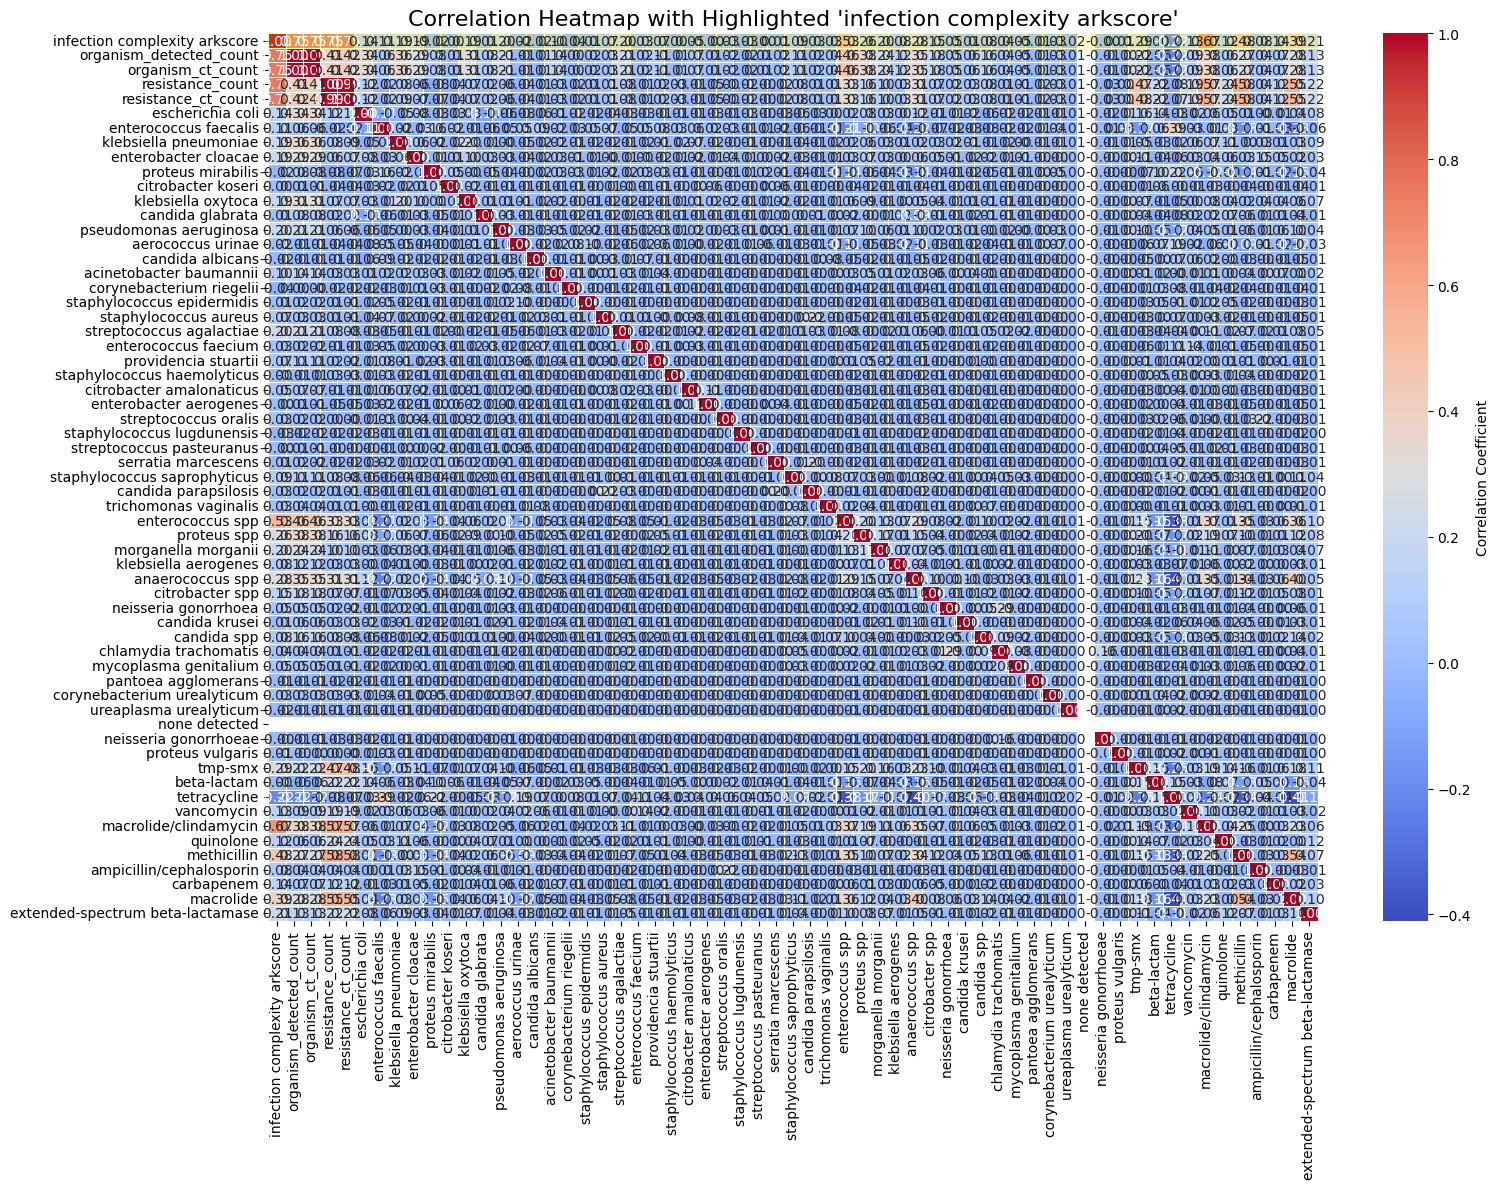

In [299]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Encode the 'primary_drug' column
label_encoder = LabelEncoder()
ml_df_ct['primary_drug_encoded'] = label_encoder.fit_transform(ml_df_ct['primary_drug'])

# Optional: display mapping of labels to original values
drug_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Drug Encoding Mapping:")
for drug, code in drug_mapping.items():
    print(f"{code}: {drug}")

# Ensure the 'infection complexity arkscore' is numeric
ml_df_ct['infection complexity arkscore'] = pd.to_numeric(ml_df_ct['infection complexity arkscore'], errors='coerce')

# Select numerical columns, including the newly encoded column
corr_columns = ml_df_ct.select_dtypes(include=['float64', 'int64']).copy()

# Calculate the correlation matrix
corr_matrix = corr_columns.corr()

# Plot Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, 
            cbar_kws={'label': 'Correlation Coefficient'})

# Highlight the 'infection complexity arkscore' row and column
highlight = corr_matrix.index[corr_matrix.index == 'infection complexity arkscore'].tolist()[0]
for tick in corr_matrix.columns:
    plt.gca().add_patch(plt.Rectangle((corr_matrix.columns.get_loc(tick), corr_matrix.index.get_loc(highlight)), 
                                     1, 1, color='yellow', alpha=0.2))

plt.title("Correlation Heatmap with Highlighted 'infection complexity arkscore'", fontsize=16)
plt.tight_layout()
plt.show()


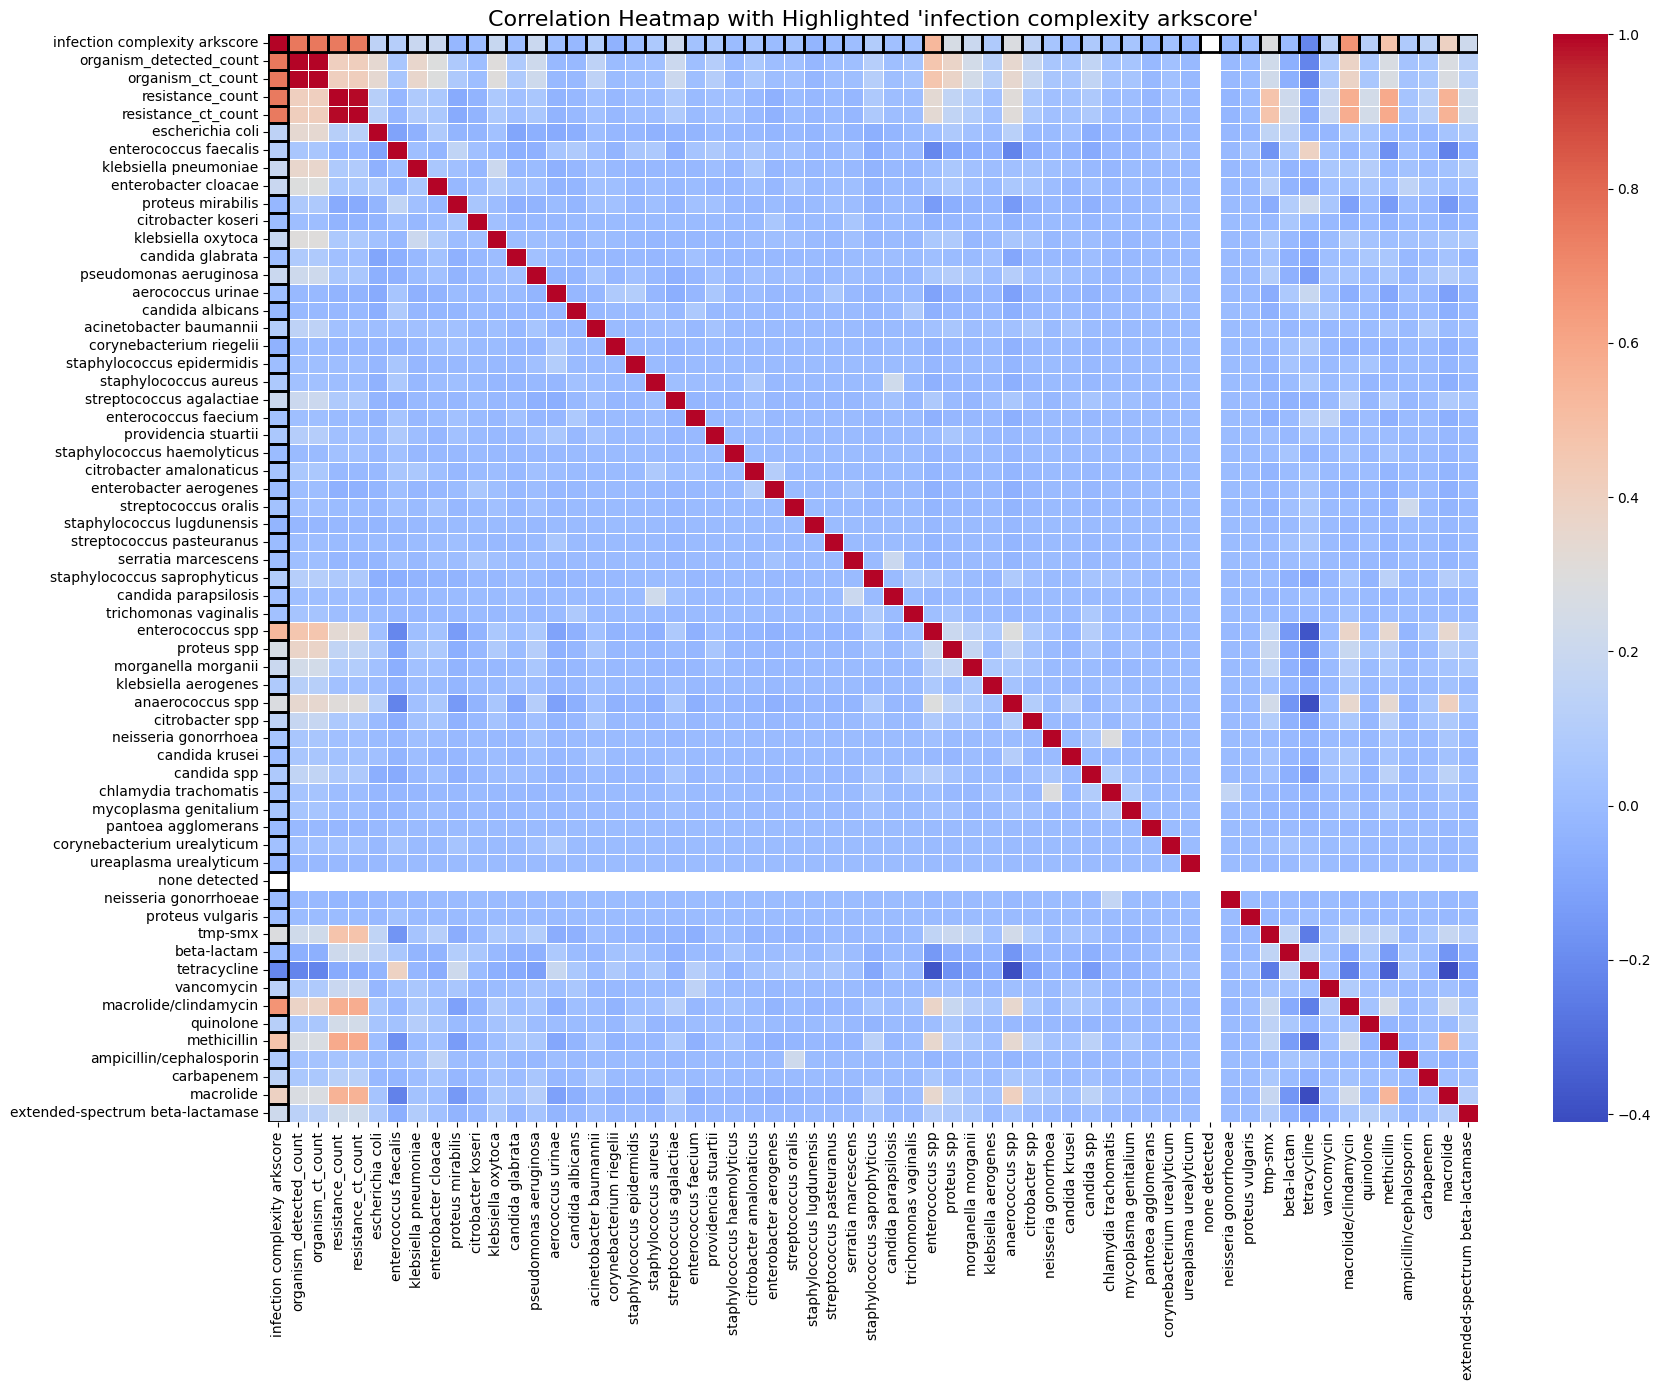

In [296]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'infection complexity arkscore' to numeric (if it's not already)
ml_df_ct['infection complexity arkscore'] = pd.to_numeric(ml_df_ct['infection complexity arkscore'], errors='coerce')

# Select numeric columns
numeric_df = ml_df_ct.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 14))

# Plot the heatmap
ax = sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, linewidths=0.5, cbar=True)

# Highlight borders for correlations with 'infection complexity arkscore'
highlight_col = 'infection complexity arkscore'
if highlight_col in correlation_matrix.columns:
    idx = correlation_matrix.columns.get_loc(highlight_col)
    for i in range(len(correlation_matrix)):
        ax.add_patch(plt.Rectangle((idx, i), 1, 1, fill=False, edgecolor='black', lw=2))
        ax.add_patch(plt.Rectangle((i, idx), 1, 1, fill=False, edgecolor='black', lw=2))

plt.title("Correlation Heatmap with Highlighted 'infection complexity arkscore'", fontsize=16)
plt.tight_layout()
plt.show()


### Alternate drug treatment

In [234]:
alt_drug_treat_df = pd.read_csv("alternate_drug_operation_useful.csv")

In [235]:
# Step 1: Create matching keys
alt_drug_treat_df["key"] = alt_drug_treat_df["accession id."].astype(str) + "||" + alt_drug_treat_df["alternate_drug_options"].astype(str)
ml_df_ct["key"] = ml_df_ct["accession id."].astype(str) + "||" + ml_df_ct["alternate_drug_options"].astype(str)

# Step 2: Drop duplicate keys in alt_drug_treat_df (i.e., conflicting entries)
alt_clean = alt_drug_treat_df.drop_duplicates(subset="key", keep=False)

# Step 3: Create mapping dictionary from cleaned DataFrame
alt_mapping = alt_clean.set_index("key")["alternative treatment options"].to_dict()

# Step 4: Use map to only update matched keys, keep existing values otherwise
ml_df_ct["alternative treatment options"] = ml_df_ct.apply(
    lambda row: alt_mapping.get(row["key"], row["alternative treatment options"]),
    axis=1
)

# Step 5: Drop helper column
ml_df_ct.drop(columns="key", inplace=True)
alt_drug_treat_df.drop(columns="key", inplace=True, errors='ignore')


In [236]:
# Clean each treatment option line by line
ml_df_ct["alternative treatment options"] = ml_df_ct["alternative treatment options"].apply(
    lambda x: "\n".join([line.strip() for line in x.split("\n")]) if isinstance(x, str) else x
)


In [237]:
ml_df_ct["alternative treatment options"][0]

'Macrobid 100 mg PO BID x 5 days\nCephalexin 250-500 mg PO QID x 5 days\nFosfomycin 3 gm PO x 1 dose\nAmox/Clav 500/125 mg PO BID x 5-7 days\nCipro 250-500 mg PO BID x 3 days'

In [238]:
# ml_df_ct.to_excel("data_after_alternate_processing.xlsx",index=False)

# data after Alternate processing 

In [2]:
import pandas as pd

ml_df_ct = pd.read_excel("data_after_alternate_processing.xlsx")
# Function to extract drug names
def extract_drug_names(text):
    if isinstance(text, str):
        lines = text.split("\n")
        return [line.strip().split()[0] for line in lines if line.strip()]
    return []

# Create a new DataFrame with accession id and extracted drug names
drug_name_df = pd.DataFrame({
    "accession id.": ml_df_ct["accession id."],
    "drug_names": ml_df_ct["alternative treatment options"].apply(extract_drug_names)
})

# Preview the result
# Counter(drug_name_df["drug_names"].explode())

In [3]:
ml_df_ct.columns

Index(['accession id.', 'organism detected', 'ct mean', 'one choice drug info',
       'resistance detected', 'resistance ct mean', 'primary_drug',
       'alternate_drug_options', 'alternative treatment options',
       'organism_detected_count', 'organism_ct_count', 'resistance_count',
       'resistance_ct_count', 'escherichia coli', 'enterococcus faecalis',
       'klebsiella pneumoniae', 'enterobacter cloacae', 'proteus mirabilis',
       'citrobacter koseri', 'klebsiella oxytoca', 'candida glabrata',
       'pseudomonas aeruginosa', 'aerococcus urinae', 'candida albicans',
       'acinetobacter baumannii', 'corynebacterium riegelii',
       'staphylococcus epidermidis', 'staphylococcus aureus',
       'streptococcus agalactiae', 'enterococcus faecium',
       'providencia stuartii', 'staphylococcus haemolyticus',
       'citrobacter amalonaticus', 'enterobacter aerogenes',
       'streptococcus oralis', 'staphylococcus lugdunensis',
       'streptococcus pasteuranus', 'serratia m

In [241]:
ml_df_ct.shape

(5449, 73)

In [242]:
ml_df_ct["drug_name"] = ml_df_ct["drug_name"].str.strip()

ml_df_ct["dose"] = ml_df_ct["dose"].str.strip()

ml_df_ct["duration"] = ml_df_ct["duration"].str.strip()

ml_df_ct["concentration"] = ml_df_ct["concentration"].str.strip()

In [243]:
ml_df_ct["drug_name"].value_counts().index

Index(['Nitrofurantoin (Macrobid)', 'Trimethoprim-Sulfamethoxazole',
       'Amoxicillin', 'Fosfomycin', 'not applicable',
       'Amoxicillin Clavulanate', 'Levofloxacin', 'Ciprofloxacin', 'Linezolid',
       'Levofloxacin, Nitrofurantoin (Macrobid)', 'Cephalexin',
       'Nitrofurantoin (Macrobid), Amoxicillin',
       'Trimethoprim-Sulfamethoxazole, Amoxicillin',
       'Nitrofurantoin (Macrobid), Ciprofloxacin', 'Fosfomycin, Amoxicillin',
       'Ceftriaxone', 'Doxycycline, Moxifloxacin',
       'Nitrofurantoin (Macrobid), Levofloxacin', 'Doxycycline',
       'Metronidazole', 'Ampicillin', 'Amox/Clav',
       'Amoxicillin, Nitrofurantoin (Macrobid)',
       'Fosfomycin, Trimethoprim-Sulfamethoxazole', 'Pip/Taz',
       'Ciprofloxacin, Nitrofurantoin (Macrobid)',
       'Trimethoprim-Sulfamethoxazole, Linezolid', 'Cefixime',
       'Linezolid, Nitrofurantoin (Macrobid)', 'Levofloxacin, Cephalexin',
       'Doxycycline, Azithromycin', 'Levofloxacin, Linezolid',
       'Amoxicillin, T

### Adding dosage ad , side effect  , interaction

In [244]:
from Organism_detected import process_organism_data

In [245]:
d_se_i_df = pd.read_excel("ARKSTONE UTI _3_columns.xlsx")

In [246]:
d_se_i_df.columns = d_se_i_df.columns.str.lower()
d_se_i_df = process_organism_data(d_se_i_df)

Step 1: Dropped rows with NaN in accession_no and reset index.
Data shape after Step 1:  (5811, 28)
Step 2: Dropped duplicate rows based on [accession_no, organism_detected, resistance_detected] and reset index.
Data shape after Step 2:  (5529, 28)
Null values before in organism_detected:  60
Null values after in organism_detected:  0
Step 4: Converting organism_detected column to string and performing cleanup.
Step 5: Converted organism_detected to lowercase and stripped extra spaces.
Step 6: Replaced commas with newline characters in organism_detected.
Step 7: Split organism_detected into lists and removed empty entries.
Step 8: Replaced 'nill' with 'none detected' in organism_detected.
Step 9: Loaded organism name dictionary from JSON file.
Step 10: Mapping organisms using the organism name dictionary.
Step 10: Organisms have been standardized using the dictionary.
Step 11: Counts of standardized organisms:
Counter({'escherichia coli': 2883, 'anaerococcus spp': 1372, 'enterococcus s

In [247]:
ml_df_ct = process_organism_data(ml_df_ct)

Step 1: Dropped rows with NaN in accession_no and reset index.
Data shape after Step 1:  (5449, 73)
Step 2: Dropped duplicate rows based on [accession_no, organism_detected, resistance_detected] and reset index.
Data shape after Step 2:  (5041, 73)
Null values before in organism_detected:  0
Null values after in organism_detected:  0
Step 4: Converting organism_detected column to string and performing cleanup.
Step 5: Converted organism_detected to lowercase and stripped extra spaces.
Step 6: Replaced commas with newline characters in organism_detected.
Step 7: Split organism_detected into lists and removed empty entries.
Step 8: Replaced 'nill' with 'none detected' in organism_detected.
Step 9: Loaded organism name dictionary from JSON file.
Step 10: Mapping organisms using the organism name dictionary.
Step 10: Organisms have been standardized using the dictionary.
Step 11: Counts of standardized organisms:
Counter({'escherichia coli': 2588, 'anaerococcus spp': 1359, 'enterococcus sp

In [248]:
d_se_i_df = d_se_i_df[['accession id.','organism detected','resistance detected', "dosing adj","side effects","interactions"]]

In [249]:
del d_se_i_df["resistance detected"]

In [250]:
# First, convert 'organism detected' to string (if it is list)
ml_df_ct['organism detected'] = ml_df_ct['organism detected'].apply(
    lambda x: ', '.join(sorted(x)) if isinstance(x, list) else x
)
d_se_i_df['organism detected'] = d_se_i_df['organism detected'].apply(
    lambda x: ', '.join(sorted(x)) if isinstance(x, list) else x
)

In [251]:
d_se_i_df = d_se_i_df.drop_duplicates(subset=['accession id.', 'organism detected'])


In [252]:

# Now merge
merged_df = pd.merge(
    ml_df_ct,
    d_se_i_df[['accession id.', 'organism detected', 'dosing adj', 'side effects', 'interactions']],
    on=['accession id.', 'organism detected'],
    how='left'
)


In [253]:
print("merged_df",merged_df.shape)
print("ml_df_ct",ml_df_ct.shape)

merged_df (5041, 76)
ml_df_ct (5041, 73)


In [254]:
dup_check = merged_df.groupby(['accession id.', 'organism detected']).size()
dup_check = dup_check[dup_check > 1]
print(dup_check)


accession id.  organism detected                                   
MU240504020    anaerococcus spp, enterococcus spp, escherichia coli    2
MU240507032    anaerococcus spp                                        2
MU240514013    anaerococcus spp, escherichia coli                      2
MU240516025    anaerococcus spp                                        2
MU240524045    escherichia coli                                        2
MU240524068    escherichia coli                                        2
MU240530032    anaerococcus spp, enterococcus spp, escherichia coli    2
MU240605025    anaerococcus spp, escherichia coli                      2
MU240610010    anaerococcus spp                                        2
MU240611012    anaerococcus spp, enterococcus spp                      2
dtype: int64


In [255]:
merged_df.columns

Index(['accession id.', 'organism detected', 'ct mean', 'one choice drug info',
       'resistance detected', 'resistance ct mean', 'primary_drug',
       'alternate_drug_options', 'alternative treatment options',
       'organism_detected_count', 'organism_ct_count', 'resistance_count',
       'resistance_ct_count', 'escherichia coli', 'enterococcus faecalis',
       'klebsiella pneumoniae', 'enterobacter cloacae', 'proteus mirabilis',
       'citrobacter koseri', 'klebsiella oxytoca', 'candida glabrata',
       'pseudomonas aeruginosa', 'aerococcus urinae', 'candida albicans',
       'acinetobacter baumannii', 'corynebacterium riegelii',
       'staphylococcus epidermidis', 'staphylococcus aureus',
       'streptococcus agalactiae', 'enterococcus faecium',
       'providencia stuartii', 'staphylococcus haemolyticus',
       'citrobacter amalonaticus', 'enterobacter aerogenes',
       'streptococcus oralis', 'staphylococcus lugdunensis',
       'streptococcus pasteuranus', 'serratia m

In [166]:
# merged_df.drop(columns=['organism_detected_count', 'organism_ct_count', 'resistance_count',
#        'resistance_ct_count','escherichia coli', 'enterococcus faecalis',
#        'klebsiella pneumoniae', 'enterobacter cloacae', 'proteus mirabilis',
#        'citrobacter koseri', 'klebsiella oxytoca', 'candida glabrata',
#        'pseudomonas aeruginosa', 'aerococcus urinae', 'candida albicans',
#        'acinetobacter baumannii', 'corynebacterium riegelii',
#        'staphylococcus epidermidis', 'staphylococcus aureus',
#        'streptococcus agalactiae', 'enterococcus faecium',
#        'providencia stuartii', 'staphylococcus haemolyticus',
#        'citrobacter amalonaticus', 'enterobacter aerogenes',
#        'streptococcus oralis', 'staphylococcus lugdunensis',
#        'streptococcus pasteuranus', 'serratia marcescens',
#        'staphylococcus saprophyticus', 'candida parapsilosis',
#        'trichomonas vaginalis', 'enterococcus spp', 'proteus spp',
#        'morganella morganii', 'klebsiella aerogenes', 'anaerococcus spp',
#        'citrobacter spp', 'neisseria gonorrhoea', 'candida krusei',
#        'candida spp', 'chlamydia trachomatis', 'mycoplasma genitalium',
#        'pantoea agglomerans', 'corynebacterium urealyticum',
#        'ureaplasma urealyticum', 'none detected', 'neisseria gonorrhoeae',
#        'proteus vulgaris', 'tmp-smx', 'beta-lactam', 'tetracycline',
#        'vancomycin', 'macrolide/clindamycin', 'quinolone', 'methicillin',
#        'ampicillin/cephalosporin', 'carbapenem', 'macrolide',
#        'extended-spectrum beta-lactamase']).to_excel("ML_ready_data_with_extra_3_columns.xlsx",index=False)

In [5]:
# pd.DataFrame(list(ml_df_ct["drug_name"].value_counts().index)).to_csv("Primary_drug.csv",index=False)

### get_adverse_reaction_arkscores

In [256]:
import pandas as pd

# ARK score dictionary (same as provided earlier)
drug_arkscore = {
    'Nitrofurantoin (Macrobid)': '3',
    'Trimethoprim-Sulfamethoxazole': '2',
    'Amoxicillin': '1',
    'Fosfomycin': '1',
    'not applicable': '-',
    'Amoxicillin Clavulanate': '1',
    'Levofloxacin': '5',
    'Ciprofloxacin': '5',
    'Linezolid': '4',
    'Levofloxacin, Nitrofurantoin (Macrobid)': '5,3',
    'Cephalexin': '1',
    'Nitrofurantoin (Macrobid), Amoxicillin': '3,1',
    'Trimethoprim-Sulfamethoxazole, Amoxicillin': '2,1',
    'Nitrofurantoin (Macrobid), Ciprofloxacin': '3,5',
    'Fosfomycin, Amoxicillin': '1,1',
    'Ceftriaxone': '2',
    'Doxycycline, Moxifloxacin': '2,5',
    'Nitrofurantoin (Macrobid), Levofloxacin': '3,5',
    'Doxycycline': '2',
    'Metronidazole': '2',
    'Ampicillin': '1',
    'Amox/Clav': '2',
    'Amoxicillin, Nitrofurantoin (Macrobid)': '1,3',
    'Fosfomycin, Trimethoprim-Sulfamethoxazole': '1,2',
    'Pip/Taz': '4',
    'Ciprofloxacin, Nitrofurantoin (Macrobid)': '5,3',
    'Trimethoprim-Sulfamethoxazole, Linezolid': '2,4',
    'Cefixime': '1',
    'Linezolid, Nitrofurantoin (Macrobid)': '4,3',
    'Levofloxacin, Cephalexin': '5,1',
    'Doxycycline, Azithromycin': '2,1',
    'Levofloxacin, Linezolid': '5,4',
    'Amoxicillin, TrimethoprimSulfamethoxazole': '1,2',
    'Levofloxacin, Amoxicillin Clavulanate': '5,1',
    'Amikacin': '5',
    'Gentamicin': '5',
    'Trimethoprim-Sulfamethoxazole, Nitrofurantoin (Macrobid)': '2,3',
    'Levofloxacin, Amoxicillin': '5,1',
    'Ciprofloxacin, Amoxicillin': '5,1',
    'Amoxicillin, Fosfomycin': '1,1'
}

# Function to fetch ARK score for a given drug, returns a single score
def get_adverse_reaction_arkscores(drug_input):
    drug_input = drug_input.split(",")  # Split input if there are multiple drugs
    for drug in drug_input:
        drug = drug.strip()  # Remove any leading/trailing spaces
        if drug in drug_arkscore:
            score_str = drug_arkscore[drug]
            # Handle case when the score is 'not applicable' or '-'
            if score_str == '-':
                return 1  # Return 1 for "not applicable"
            score_list = score_str.split(',')
            try:
                # Convert the first score to an integer
                score = int(score_list[0])
                return score
            except ValueError:
                # In case there's an issue converting to int, return default score
                return 1
    return 1  # If no ARK score found, return default score


### import get_adverse_reaction_arkscores

In [289]:
from arkscore_calculator import get_adverse_reaction_arkscores, get_antimicrobial_resistance_arkscore
# a= ml_df_ct["drug_name"].apply(get_adverse_reaction_arkscores)

In [290]:
ml_df_ct['adverse_reaction_arkscores']= ml_df_ct["drug_name"].apply(get_adverse_reaction_arkscores)

KeyError: 'drug_name'

In [291]:
ml_df_ct[["drug_name","adverse_reaction_arkscores"]]

KeyError: "None of [Index(['drug_name', 'adverse_reaction_arkscores'], dtype='object')] are in the [columns]"

In [263]:
corr_df = ml_df_ct.copy()

In [ ]:
corr_df.drop(columns=[])

In [262]:
ml_df_ct.columns

Index(['accession id.', 'organism detected', 'ct mean', 'one choice drug info',
       'resistance detected', 'resistance ct mean', 'primary_drug',
       'alternate_drug_options', 'alternative treatment options',
       'organism_detected_count', 'organism_ct_count', 'resistance_count',
       'resistance_ct_count', 'escherichia coli', 'enterococcus faecalis',
       'klebsiella pneumoniae', 'enterobacter cloacae', 'proteus mirabilis',
       'citrobacter koseri', 'klebsiella oxytoca', 'candida glabrata',
       'pseudomonas aeruginosa', 'aerococcus urinae', 'candida albicans',
       'acinetobacter baumannii', 'corynebacterium riegelii',
       'staphylococcus epidermidis', 'staphylococcus aureus',
       'streptococcus agalactiae', 'enterococcus faecium',
       'providencia stuartii', 'staphylococcus haemolyticus',
       'citrobacter amalonaticus', 'enterobacter aerogenes',
       'streptococcus oralis', 'staphylococcus lugdunensis',
       'streptococcus pasteuranus', 'serratia m

In [260]:
# Apply get_arkscore function to the 'drug_name' column and store results in the new column
# ml_df_ct['adverse_reaction_arkscores'] = ml_df_ct['drug_name'].apply()


In [ ]:
# Input from user (you can replace this with input from any source like a list)
user_input = input("Enter drug(s) name(s), separated by commas: ")

# Get ARK scores for the input drugs
ark_scores = get_arkscore(user_input)

# Print the ARK scores (now stored as integers)
print("ARK Scores for the given drugs (as integers):", ark_scores)

In [136]:
# Input from user (you can replace this with input from any source like a list)
user_input = input("Enter drug(s) name(s), separated by commas: ")

# Get ARK scores for the input drugs
ark_scores = get_arkscore(user_input)

# Print the ARK scores
print("ARK Scores for the given drugs: ", ", ".join(ark_scores))

Enter drug(s) name(s), separated by commas:  Ampicillin


ARK Scores for the given drugs:  1


In [5]:
ml_df_ct.columns

Index(['accession id.', 'organism detected', 'ct mean', 'one choice drug info',
       'resistance detected', 'resistance ct mean', 'primary_drug',
       'alternate_drug_options', 'alternative treatment options',
       'organism_detected_count', 'organism_ct_count', 'resistance_count',
       'resistance_ct_count', 'escherichia coli', 'enterococcus faecalis',
       'klebsiella pneumoniae', 'enterobacter cloacae', 'proteus mirabilis',
       'citrobacter koseri', 'klebsiella oxytoca', 'candida glabrata',
       'pseudomonas aeruginosa', 'aerococcus urinae', 'candida albicans',
       'acinetobacter baumannii', 'corynebacterium riegelii',
       'staphylococcus epidermidis', 'staphylococcus aureus',
       'streptococcus agalactiae', 'enterococcus faecium',
       'providencia stuartii', 'staphylococcus haemolyticus',
       'citrobacter amalonaticus', 'enterobacter aerogenes',
       'streptococcus oralis', 'staphylococcus lugdunensis',
       'streptococcus pasteuranus', 'serratia m

In [6]:
prm_alt_df = ml_df_ct.drop(columns=['organism detected', 'ct mean', 'one choice drug info',
       'resistance detected', 'resistance ct mean', 'primary_drug',
       'alternate_drug_options', 'organism_detected_count',
                                     # 'alternative treatment options',
       'organism_ct_count', 'resistance_count', 'resistance_ct_count']).reset_index(drop=True)
import numpy as np

# Define the columns you want to clean
columns_to_clean = ['drug_name', 'concentration', 'dose', 'duration']

# Clean and split each column by commas, removing blank spaces
for col in columns_to_clean:
    prm_alt_df[f"{col}"] = prm_alt_df[col].apply(
        lambda x: [val.strip() for val in str(x).split(",") if val.strip()]
    )

# Create the target_1 column by combining the relevant columns
def create_target(row):
    try:
        # Get the lists for each column
        drug_list = row["drug_name"]
        conc_list = row["concentration"]
        dose_list = row["dose"]
        dur_list = row["duration"]

        # Minimum length to avoid IndexError if lists are mismatched
        min_len = min(len(drug_list), len(conc_list), len(dose_list), len(dur_list))

        # Create a combined string for each index
        combined = [
            f"{drug_list[j]} | {conc_list[j]} | {dose_list[j]} | {dur_list[j]}"
            for j in range(min_len)
        ]
        return combined if combined else np.nan  # Return NaN if the combined list is empty
    except Exception as e:
        return np.nan  # If there's an error, return NaN

# Apply the function to create the target_1 column
prm_alt_df['target_1'] = prm_alt_df.apply(create_target, axis=1)

# Drop the original columns as you no longer need them
prm_alt_df.drop(columns=['concentration', 'dose', 'duration', 'drug_name'], inplace=True)

prm_alt_df["alternative treatment options"] = prm_alt_df["alternative treatment options"].str.replace("  "," ")
prm_alt_df["alternative treatment options"] = prm_alt_df["alternative treatment options"].str.replace("   "," ")

## dropping unnecessary

In [7]:
prm_alt_df.drop(index=[1583, 1943, 2840, 3323, 3349, 3710, 3753, 4252, 4305, 4422, 2971],inplace=True)
prm_alt_df = prm_alt_df.reset_index(drop=True)

## Target_1 encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
target_1_encoder = LabelEncoder()

# Apply Label Encoding to the 'target_1' column and store the result in a new column
prm_alt_df['target_1_encoded'] = target_1_encoder.fit_transform(prm_alt_df['target_1'].astype(str))

del prm_alt_df["target_1"]

## Target_2 encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
target_2_encoder = LabelEncoder()

# Apply Label Encoding to the 'alternative treatment options' column and store the result in a new column 'target_2'
prm_alt_df['target_2'] = target_2_encoder.fit_transform(prm_alt_df['alternative treatment options'].astype(str))

del prm_alt_df["alternative treatment options"]

In [10]:
accession_id = prm_alt_df["accession id."]

In [11]:
del prm_alt_df["accession id."]

## XG boost

### Random Forest

### train_model_1 full

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Step 1: Separate features and targets
X = prm_alt_df.drop(columns=["target_1_encoded", "target_2"])
y1 = prm_alt_df["target_1_encoded"]
y2 = prm_alt_df["target_2"]

# ✅ Step 2: Train model_1 on 100% of data to predict target_1
model_1 = RandomForestClassifier(random_state=42)
model_1.fit(X, y1)

RandomForestClassifier(random_state=42)

In [13]:
# Predict target_1 for full data
y1_pred_full = model_1.predict(X)

## train with 100 % 

In [14]:
# Add predicted target_1 as a new feature
X_with_y1_pred = X.copy()
X_with_y1_pred["target_1_encoded"] = y1_pred_full

# ✅ Train model_2 to predict target_2 on full data
model_2 = RandomForestClassifier(random_state=42)
model_2.fit(X_with_y1_pred, y2)

# Predict on the same data (optional: use different data in production)
y2_pred = model_2.predict(X_with_y1_pred)

print("\n🔹 Classification Report for target_2 (trained & predicted on same data):")
print(classification_report(y2, y2_pred, zero_division=0))


🔹 Classification Report for target_2 (trained & predicted on same data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       0.00      0.00      0.00         1
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         1
          15       0.50      1.00      0.67         1
       

### Prediction

In [15]:
from prompt_toolkit import prompt
import pandas as pd

# 👉 Replace with your actual trained models and label encoders
model_1 = model_1
model_2 = model_2
le_target_1 = target_1_encoder
le_target_2 = target_2_encoder

### Save these model 

In [16]:
import pickle

# Assuming model_1, model_2, target_1_encoder, target_2_encoder are already defined

# Create a dictionary with all models and encoders
models_and_encoders = {
    'model_1': model_1,
    'model_2': model_2,
    'target_1_encoder': target_1_encoder,
    'target_2_encoder': target_2_encoder
}

# Define the file path for saving the entire dictionary
FILE_PATH = "models_and_encoders.pkl"

# Save the dictionary as a pickle file
with open(FILE_PATH, 'wb') as f:
    pickle.dump(models_and_encoders, f)

print("Models and encoders have been saved as a dictionary successfully.")


Models and encoders have been saved as a dictionary successfully.


In [ ]:
# 🔹 Feature list
all_features = [
    'escherichia coli', 'enterococcus faecalis', 'klebsiella pneumoniae',
    'enterobacter cloacae', 'proteus mirabilis', 'citrobacter koseri',
    'klebsiella oxytoca', 'candida glabrata', 'pseudomonas aeruginosa',
    'aerococcus urinae', 'candida albicans', 'acinetobacter baumannii',
    'corynebacterium riegelii', 'staphylococcus epidermidis',
    'staphylococcus aureus', 'streptococcus agalactiae',
    'enterococcus faecium', 'providencia stuartii',
    'staphylococcus haemolyticus', 'citrobacter amalonaticus',
    'enterobacter aerogenes', 'streptococcus oralis',
    'staphylococcus lugdunensis', 'streptococcus pasteuranus',
    'serratia marcescens', 'staphylococcus saprophyticus',
    'candida parapsilosis', 'trichomonas vaginalis', 'enterococcus spp',
    'proteus spp', 'morganella morganii', 'klebsiella aerogenes',
    'anaerococcus spp', 'citrobacter spp', 'neisseria gonorrhoea',
    'candida krusei', 'candida spp', 'chlamydia trachomatis',
    'mycoplasma genitalium', 'pantoea agglomerans',
    'corynebacterium urealyticum', 'ureaplasma urealyticum',
    'none detected', 'neisseria gonorrhoeae', 'proteus vulgaris', 'tmp-smx',
    'beta-lactam', 'tetracycline', 'vancomycin', 'macrolide/clindamycin',
    'quinolone', 'methicillin', 'ampicillin/cephalosporin', 'carbapenem',
    'macrolide', 'extended-spectrum beta-lactamase',
]

input_features = {}

print("👉 Enter feature name, then input CT value. Type 'done' to finish.\n")

while True:
    feature = prompt("Feature: ").strip().lower()
    if feature == 'done':
        break
    if feature not in all_features:
        print("❌ Feature not recognized. Try again.")
        continue
    try:
        value = float(input(f"CT value for '{feature}': "))
        input_features[feature] = value
    except ValueError:
        print("❌ Please enter a valid float value.")

# 🔹 Fill remaining features with 0.0
full_input = {feat: input_features.get(feat, 0.0) for feat in all_features}
input_df = pd.DataFrame([full_input])

# 🔹 Predict target_1
y1_pred = model_1.predict(input_df)
input_df['target_1_encoded'] = y1_pred

# 🔹 Predict target_2
y2_pred = model_2.predict(input_df)

# 🔹 Decode
decoded_y1 = target_1_encoder.inverse_transform(y1_pred)[0]
decoded_y2 = target_2_encoder.inverse_transform(y2_pred)[0]

# ✅ Final Output
print("\n🎯 Predicted Results:")
print(f"🔹 Target 1: {decoded_y1}")
print(f"🔹 Target 2: {decoded_y2}")

👉 Enter feature name (with tab-completion), then input CT value. Type 'done' to finish.

Feature:








In [46]:
# Add predicted target_1 as a new feature
X_with_y1_pred = X.copy()
X_with_y1_pred["target_1_encoded"] = y1_pred_full

# ✅ Step 3: Split data for model_2 (target_2 prediction)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_with_y1_pred, y2, test_size=0.5, random_state=42
)

# ✅ Step 4: Train model_2 to predict target_2
model_2 = RandomForestClassifier(random_state=42)
model_2.fit(X_train_2, y_train_2)

# Predict and evaluate
y2_pred = model_2.predict(X_test_2)

print("\n🔹 Classification Report for target_2:")
print(classification_report(y_test_2, y2_pred, zero_division=0))


🔹 Classification Report for target_2:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           2       0.50      0.50      0.50         2
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           6       0.20      1.00      0.33         1
           7       0.00      0.00      0.00         0
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          11       1.00      1.00      1.00         1
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0
          16       0.20      0.25      0.22         4
          17       1.00      0.25      0.40         4
          18       0.00      0.00      0.0

# ML model CT mean only primary

In [94]:
ct_mean_df = ml_df_ct.drop(columns=['organism detected', 'ct mean', 'one choice drug info',
       'resistance detected', 'resistance ct mean', 'primary_drug',
       'alternate_drug_options', 
       'alternative treatment options',
       'organism_detected_count',
       'organism_ct_count', 'resistance_count', 'resistance_ct_count']).reset_index(drop=True)

In [95]:
# ct_mean_df.to_csv("ct_mean_traing_data.csv",index=False)
# ct_mean_df = pd.read_csv("ct_mean_traing_data.csv")

len(ct_mean_df.columns)

61

In [53]:
ct_mean_df

,accession id.,escherichia coli,enterococcus faecalis,klebsiella pneumoniae,enterobacter cloacae,proteus mirabilis,citrobacter koseri,klebsiella oxytoca,candida glabrata,pseudomonas aeruginosa,...,quinolone,methicillin,ampicillin/cephalosporin,carbapenem,macrolide,extended-spectrum beta-lactamase,concentration,dose,duration,drug_name
0,UXX231108005,16.78,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,DS 1 tab,PO BID,3 days,Trimethoprim-Sulfamethoxazole
1,UXX231108003,22.70,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,100 mg,PO BID,7 days,Nitrofurantoin (Macrobid)
2,UXX231107042,23.85,23.57,17.32,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,100 mg,PO BID,5 days,Nitrofurantoin (Macrobid)
3,UXX231107040,22.38,20.44,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,100 mg,PO BID,5 days,Nitrofurantoin (Macrobid)
4,UXX231107038,0.00,20.52,23.99,20.82,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,100 mg,PO BID,5 days,Nitrofurantoin (Macrobid)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5444,MU250404075,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Info Unavailable,Info Unavailable,Info Unavailable,not applicable
5445,MU250404074,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Info Unavailable,Info Unavailable,Info Unavailable,not applicable
5446,MU250404048,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Info Unavailable,Info Unavailable,Info Unavailable,not applicable
5447,MU250404098,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Info Unavailable,Info Unavailable,Info Unavailable,not applicable


In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load the data
# data = pd.read_csv('ct_mean_traing_data.csv')
data = ct_mean_df

# Combine 'drug_name', 'concentration', 'dose', and 'duration' into a single string
data['combined_target'] = data.apply(lambda row: f"{row['drug_name']} {row['concentration']} {row['dose']} {row['duration']}", axis=1)

# Encode the combined target variable
label_encoder = LabelEncoder()
data['encoded_target'] = label_encoder.fit_transform(data['combined_target'])

# Define the features and target variable
X = data.drop(columns=['accession id.', 'concentration', 'dose', 'duration', 'drug_name', 'combined_target'])
y = data['encoded_target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = RandomForestClassifier(n_estimators=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"The accuracy of the model is {accuracy:.2f}")

# Decode the predictions to get the original format
decoded_predictions = label_encoder.inverse_transform(y_pred)

# Display some decoded predictions
for i in range(5):
    print(f"Decoded prediction {i+1}: {decoded_predictions[i]}")


The accuracy of the model is 0.96
Decoded prediction 1: Trimethoprim-Sulfamethoxazole DS 1 tab PO BID 3 days
Decoded prediction 2: Nitrofurantoin (Macrobid) 100 mg PO BID 5 days
Decoded prediction 3: Trimethoprim-Sulfamethoxazole DS 1 tab PO BID 3 days
Decoded prediction 4: Nitrofurantoin (Macrobid) 100 mg PO BID 5 days
Decoded prediction 5: Trimethoprim-Sulfamethoxazole DS 1 tab PO BID 3 days


# ML model 2 Preprocessing 

In [486]:
# df_backup  = df_merged.copy()
# df_merged = df_backup.copy()

In [29]:
ml_df = df_merged[["accession id.",
                   "organism detected",
                   # "one choice drug info",
                   "resistance detected",
                   "primary_drug",
                   "alternate_drug_options"]].copy()

,s.no.,accession id.,organism detected,ct mean,resistance detected,resistance ct mean,antimicrobial resistance arkscore,adverse reaction arkscore,infection complexity arkscore,dosing adj,...,drug name.1,concentration.1,dosage per day.1,duration.1,ark score,why is this the onechoice?,when should this be treated?,are there any special considerations?,primary_drug,alternate_drug_options
0,1,UXX231108005,escherichia coli,16.78,[none detected],NaN,1,2,1,Renal,...,Macrobid°\nCephalexin°\nFosfomycin\nAmox/Clav\nCipro,100 mg\n250-500 mg\n3 mg\n500/125 mg\n250-500 mg,PO BID\nPO QID\nPO\nPO BID\nPO BID,5 days\n5 days\n1 dose\n5-7 days\n3 days,3\n1\n1\n2\n5,E. coli can be pathogenic when found in urine samples. The recommended treatment is optimal as it targets all the concerning microbes. TMP-SMX efficacy against E. coli is uncertain,"Asymptomatic bacteriuria does not typically need treatment, and microbe detection may not indicate infection. However, treatment may be necessary during pregnancy or prior to urological procedures. Simple UTIs are typically treated for 3 days (fluoroquinolones/TMP-SMX), or 5 days (beta-lactams). In more complicated cases therapy may be extended to 7-14 days. STI treatment is specific to the microbe being treated and antimicrobial being used.","Patients may have colonized microbes, so a positive specimen does not necessarily mean infection. However, normal urine flora may be pathogenic at times.",trimethoprimsulfamethoxazole,"[macrobid, cephalexin, fosfomycin, amox/clav, ciprofloxacin]"
1,2,UXX231108003,escherichia coli,22.7,[tmp-smx],22.99,1,3,1,Renal,...,Cephalexin°\nFosfomycin\nAmox/Clav\nLevofloxacin,250-500 mg\n\n875/125 mg\n250-750 mg,PO QID\ndose dose not defined\nPO BID\nPO daily,7 days\nundefined duration\n10-14 days\n7 days,1\n1\n2\n5,E. coli can be pathogenic when found in urine samples. Resistance genes were detected which may limit available treatment options. The recommended treatment is optimal as it targets all the concerning microbes. Macrobid efficacy against E. coli is uncertain.,"Asymptomatic bacteriuria does not typically need treatment, and microbe detection may not indicate infection. Treatment may be necessary prior to urological procedures. UTIs are typically treated for 7 days in male patients. In more complicated cases therapy may be extended to 7-14 days. STI treatment is specific to the microbe being treated and antimicrobial being used","Patients may have colonized microbes, so a positive specimen does not necessarily mean infection. However, normal urine flora may be pathogenic at times. Resistance is variable; therefore, drug failure is possible. Resistance detected may only affect certain microbes, and in some cases, none at all.",macrobid,"[cephalexin, fosfomycin, amox/clav, levofloxacin]"
2,3,UXX231107042,enterococcus faecalis\nescherichia coli\nklebsiella pneumoniae,23.57\n23.85\n17.32\n,"[beta-lactam, tetracycline, tmp-smx, vancomycin]",17.22\n22.66 \n20.45\n26.90,4,3,4,Renal,...,Fosfomycin°\nLevofloxacin°\nGentamicin°\nPip/Taz,3 mg\n250-750 mg\n5 mg/kg\n3.375 gm,PO\nPO daily\nIV\nIV Q6H,1 dose\n3 days\n1 dose\n5-14 days,1\n5\n5\n4,"Enterococcus faecalis, E. coli and Klebsiella pneumoniae can be pathogenic when found in urine samples. Resistance genes were detected in multiple classes which may limit available treatment options. Macrobid efficacy against Klebsiella pneumoniae and E. coli is uncertain.","Asymptomatic bacteriuria does not typically need treatment, and microbe detection may not indicate infection. However, treatment may be necessary during pregnancy or prior to urological procedures. Simple UTIs are typically treated for 3 days (fluoroquinolones/TMP-SMX), or 5 days (beta-lactams). In more complicated cases therapy may be extended to 7-14 days. STI treatment is specific to the microbe being treated and antimicrobial being used.","Multiple microbes detected may indicate contamination or colonization. Enterococcus faecalis may have intrinsic resistance to cert

In [487]:
ml_df = df_merged[["accession id.",
                   "organism detected",
                   # "one choice drug info",
                   "resistance detected",
                   "primary_drug",
                   "alternate_drug_options"]].copy()

In [488]:
ml_df["organism detected"].str.split("\n").explode().unique()

array(['escherichia coli', 'enterococcus faecalis',
       'klebsiella pneumoniae', 'enterobacter cloacae',
       'proteus mirabilis', 'citrobacter koseri', 'klebsiella oxytoca',
       'candida glabrata', 'pseudomonas aeruginosa', 'aerococcus urinae',
       'candida albicans', 'acinetobacter baumannii',
       'corynebacterium riegelii', 'staphylococcus epidermidis',
       'staphylococcus aureus', 'streptococcus agalactiae',
       'enterococcus faecium', 'providencia stuartii',
       'staphylococcus haemolyticus', 'citrobacter amalonaticus',
       'enterobacter aerogenes', 'streptococcus oralis',
       'staphylococcus lugdunensis', 'streptococcus pasteuranus',
       'serratia marcescens', 'staphylococcus saprophyticus',
       'candida parapsilosis', 'trichomonas vaginalis',
       'enterococcus spp', 'proteus spp', 'morganella morganii',
       'klebsiella aerogenes', 'anaerococcus spp', 'citrobacter spp',
       'neisseria gonorrhoea', 'candida krusei', 'candida spp',
      

In [489]:
# for organism
import pandas as pd

# Assuming ml_df is your dataframe
# Step 1: Clean and split the detected organisms
organism_list = ml_df["organism detected"].str.split("\n").explode().str.strip().unique()

# Step 2: Create binary columns for each organism
for organism in organism_list:
    # Create a new column for each organism: 1 if present, 0 if not
    ml_df[organism] = ml_df["organism detected"].apply(lambda x: 1 if organism.lower() in x.lower() else 0)

# View the resulting dataframe with binary columns for each organism


# ml_df.drop(columns=[""],inplace=True)

In [490]:
ml_df.columns

Index(['accession id.', 'organism detected', 'resistance detected',
       'primary_drug', 'alternate_drug_options', 'escherichia coli',
       'enterococcus faecalis', 'klebsiella pneumoniae',
       'enterobacter cloacae', 'proteus mirabilis', 'citrobacter koseri',
       'klebsiella oxytoca', 'candida glabrata', 'pseudomonas aeruginosa',
       'aerococcus urinae', 'candida albicans', 'acinetobacter baumannii',
       'corynebacterium riegelii', 'staphylococcus epidermidis',
       'staphylococcus aureus', 'streptococcus agalactiae',
       'enterococcus faecium', 'providencia stuartii',
       'staphylococcus haemolyticus', 'citrobacter amalonaticus',
       'enterobacter aerogenes', 'streptococcus oralis',
       'staphylococcus lugdunensis', 'streptococcus pasteuranus',
       'serratia marcescens', 'staphylococcus saprophyticus',
       'candida parapsilosis', 'trichomonas vaginalis', 'enterococcus spp',
       'proteus spp', 'morganella morganii', 'klebsiella aerogenes',
      

In [491]:
ml_df["resistance detected"].explode().unique()

array(['none detected', 'tmp-smx', 'beta-lactam', 'tetracycline',
       'vancomycin', 'macrolide/clindamycin', 'quinolone', 'methicillin',
       'ampicillin/cephalosporin', 'carbapenem', 'macrolide',
       'extended-spectrum beta-lactamase'], dtype=object)

In [492]:
resistance_list = list(ml_df["resistance detected"].explode().unique())

In [493]:
import pandas as pd

# Ensure that the "resistance detected" column contains lists (we assume it is already in list format)
for resistance in resistance_list:
    print(f"Processing resistance type: {resistance}")
    
    # Create a new binary column for each resistance type: 1 if present, 0 if not
    ml_df[resistance] = ml_df["resistance detected"].apply(
        lambda x: 1 if isinstance(x, list) and resistance.lower() in [item.lower() for item in x] else 0
    )

# View the resulting dataframe with binary columns for each resistance type
# print(ml_df.head())


Processing resistance type: none detected
Processing resistance type: tmp-smx
Processing resistance type: beta-lactam
Processing resistance type: tetracycline
Processing resistance type: vancomycin
Processing resistance type: macrolide/clindamycin
Processing resistance type: quinolone
Processing resistance type: methicillin
Processing resistance type: ampicillin/cephalosporin
Processing resistance type: carbapenem
Processing resistance type: macrolide
Processing resistance type: extended-spectrum beta-lactamase


In [494]:
ml_df.describe()

,escherichia coli,enterococcus faecalis,klebsiella pneumoniae,enterobacter cloacae,proteus mirabilis,citrobacter koseri,klebsiella oxytoca,candida glabrata,pseudomonas aeruginosa,aerococcus urinae,...,beta-lactam,tetracycline,vancomycin,macrolide/clindamycin,quinolone,methicillin,ampicillin/cephalosporin,carbapenem,macrolide,extended-spectrum beta-lactamase
count,7245.000000,7245.000000,7245.00000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,...,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000,7245.000000
mean,0.541339,0.124914,0.16991,0.071498,0.061422,0.004279,0.056591,0.064320,0.084334,0.033126,...,0.062664,0.289855,0.013941,0.425949,0.061560,0.235887,0.001794,0.010490,0.287233,0.038647
std,0.498323,0.330644,0.37558,0.257672,0.240119,0.065277,0.231075,0.245339,0.277907,0.178979,...,0.242374,0.453726,0.117253,0.494520,0.240371,0.424581,0.042325,0.101889,0.452502,0.192766
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [495]:
# import pandas as pd

# # Step 1: Build reverse mapping from all synonyms to canonical names
# synonym_to_canonical = {}
# for canonical, synonyms in organism_name_dict.items():
#     for name in synonyms:
#         synonym_to_canonical[name.lower()] = canonical  # normalize to lowercase for matching

# # Step 2: Explode and normalize organism names
# ml_df_exp = ml_df[["organism detected"]].copy()
# ml_df_exp["row"] = ml_df_exp.index

# ml_df_exp = (
#     ml_df_exp["organism detected"]
#     .str.replace(", ", ",", regex=False)
#     .str.split("\n")
#     .explode()
#     .str.lower()
#     .str.strip()
#     .reset_index(name="normalized")
# )

# # Step 3: Map to canonical names
# ml_df_exp["canonical"] = ml_df_exp["normalized"].map(synonym_to_canonical)

# # Optional: check unmapped organisms
# unmapped = ml_df_exp[ml_df_exp["canonical"].isna()]["normalized"].unique()
# if len(unmapped) > 0:
#     print("Unmapped organisms:", unmapped)

# # Step 4: Create binary indicator matrix
# ml_df_onehot = pd.crosstab(ml_df_exp["index"], ml_df_exp["canonical"]).reindex(ml_df.index, fill_value=0)

# # Step 5: Join back to original DataFrame
# ml_df = ml_df.join(ml_df_onehot)

# # Step 1: Create reverse mapping from resistance synonyms to canonical names
# resistance_to_canonical = {}
# for canonical, synonyms in resistance_name_dict.items():
#     for name in synonyms:
#         resistance_to_canonical[name.lower()] = canonical  # normalize to lowercase for matching

# # Step 2: Normalize and explode the resistance values
# res_exp = ml_df[["resistance detected"]].copy()
# res_exp["row"] = res_exp.index

# res_exp = (
#     res_exp["resistance detected"]
#     .str.replace(", ", ",", regex=False)
#     .str.split("\n")
#     .explode()
#     .str.lower()
#     .str.strip()
#     .reset_index(name="normalized")
# )

# # Step 3: Map to canonical resistance names
# res_exp["canonical"] = res_exp["normalized"].map(resistance_to_canonical)

# # Optional: check for unmapped resistance values
# unmapped_res = res_exp[res_exp["canonical"].isna()]["normalized"].unique()
# if len(unmapped_res) > 0:
#     print("Unmapped resistance values:", unmapped_res)

# # Step 4: Create one-hot encoded resistance columns
# res_onehot = pd.crosstab(res_exp["index"], res_exp["canonical"]).reindex(ml_df.index, fill_value=0)

# # Step 5: Join the one-hot resistance columns back to the original DataFrame
# ml_df = ml_df.join(res_onehot)

In [496]:
# # Step 2: Initialize organism and resistance columns with 0
# for org_key in organism_name_dict:
#     ml_df[org_key] = 0

# for res_key in resistance_name_dict:
#     ml_df[res_key] = 0

# # Step 3: Populate organism columns
# def mark_organisms(row_text):
#     row_text = str(row_text).lower()
#     matched = set()
#     for org_key, aliases in organism_name_dict.items():
#         if any(alias in row_text for alias in aliases):
#             matched.add(org_key)
#     return matched

# # Step 4: Populate resistance columns
# def mark_resistance(row_text):
#     row_text = str(row_text).lower()
#     matched = set()
#     for res_key, aliases in resistance_name_dict.items(nikhilp17539@gmail.com
# ):
#         if any(alias in row_text for alias in aliases):
#             matched.add(res_key)
#     return matched

# # Step 5: Apply to dataframe
# for idx, row in ml_df.iterrows():
#     found_organisms = mark_organisms(row["organism detected"])
#     found_resistance = mark_resistance(row["resistance detected"])

#     for org in found_organisms:
#         ml_df.at[idx, org] = 1
#     for res in found_resistance:
#         ml_df.at[idx, res] = 1

# Machine learning model

In [497]:
# ml_df = ml_df.drop(columns=["PCA1","PCA2"])

In [301]:
ml_df.iloc[:,5:]

,escherichia coli,enterococcus faecalis,klebsiella pneumoniae,enterobacter cloacae,proteus mirabilis,citrobacter koseri,klebsiella oxytoca,candida glabrata,pseudomonas aeruginosa,aerococcus urinae,...,beta-lactam,tetracycline,vancomycin,macrolide/clindamycin,quinolone,methicillin,ampicillin/cephalosporin,carbapenem,macrolide,extended-spectrum beta-lactamase
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,1,1,0,1,0,0,0,0,0,0
4,0,1,1,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7240,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
7241,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
7242,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
7243,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


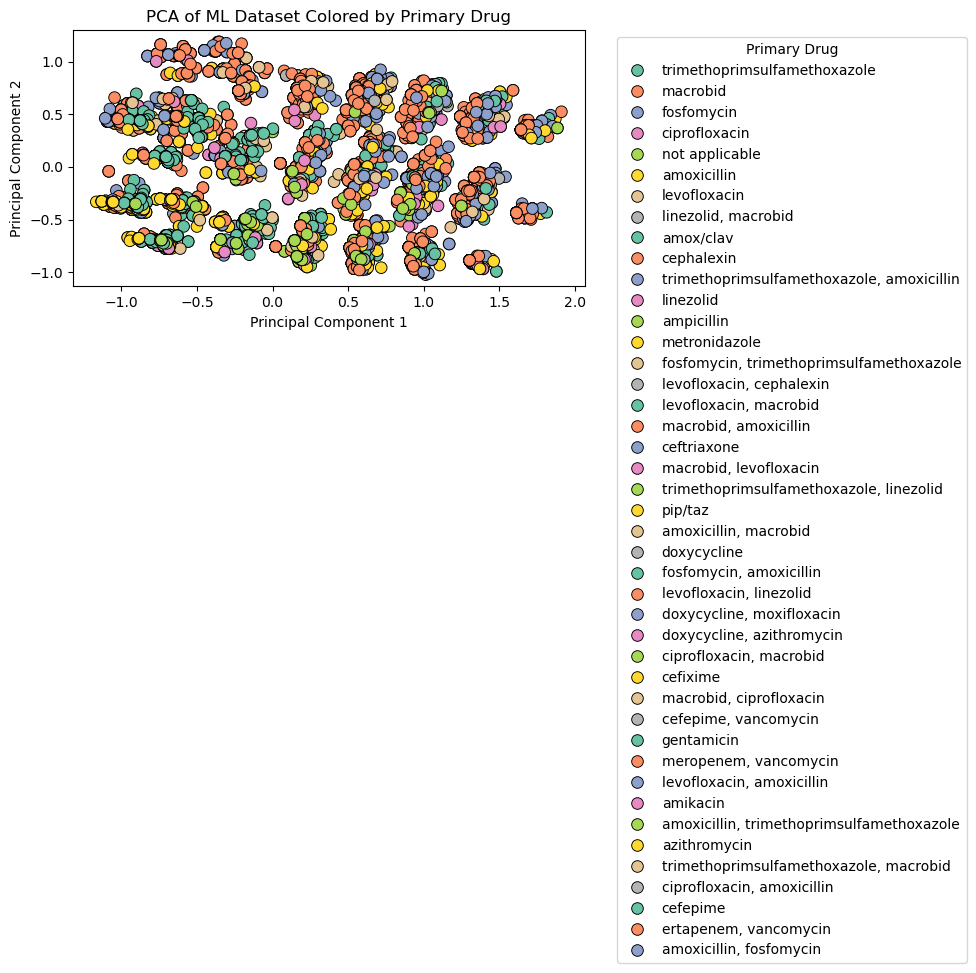

In [302]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
# organism_cols = list(organism_name_dict.keys())

# resistance_cols = list(resistance_name_dict.keys())

# # Select relevant features
# features = organism_cols + resistance_cols
X = ml_df.iloc[:,5:]
# X = X.loc[:, ~X.isin(['none detected']).any()]

# Standardize the features
# X_scaled = RobustScaler().fit_transform(X)
X_scaled = X 

# PCA transformation
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# Add PCA results back to the dataframe
ml_df['PCA1'] = pca_result[:, 0]
ml_df['PCA2'] = pca_result[:, 1]

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='primary_drug',
    palette='Set2',
    data=ml_df,
    s=70,
    edgecolor='k'
)
plt.title('PCA of ML Dataset Colored by Primary Drug')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Primary Drug', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [303]:
ml_df = ml_df.drop(columns=["PCA1","PCA2"])

In [439]:
ml_df_train = ml_df.copy()

## Train primary drug

In [498]:
ml_df_train = ml_df.copy()
### import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC


# Step 1: Remove 'One Choice Drug Info'
ml_df_train = ml_df_train.drop(columns=["alternate_drug_options",'organism detected','resistance detected'])

# Step 2: Encode target variable
label_encoder = LabelEncoder()
ml_df_train["primary_drug_encoded"] = label_encoder.fit_transform(ml_df_train["primary_drug"])

# Step 3: Define Features (X) and Target (y)
X = ml_df_train.drop(columns=["accession id.", "primary_drug", "primary_drug_encoded"])
y = ml_df_train["primary_drug_encoded"]

# Step 3.5: standardize 
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
X_scaled = X

# Step 4: Train-Test Split
# X_train, X_test, y_train, y_test, acc_train, acc_test = train_test_split(X, y, ml_df_train["Accession ID."], test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test, acc_train, acc_test = train_test_split(X_scaled, y, ml_df_train["accession id."], test_size=0.2, random_state=42)

# # Step 5: Train Random Forest
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf.fit(X_train, y_train)

# # Step 6: Predictions
# y_pred = rf.predict(X_test)

# from sklearn.svm import SVC

# Step 5: Train SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

# Step 6: Predictions
y_pred = svm.predict(X_test)

# Step 7: Reverse transform predictions
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

# Step 8: Evaluation
accuracy = accuracy_score(y_test, y_pred)
# report = classification_report(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=1)


# Display Results
print(f"🔹 Accuracy: {accuracy:.2f}")
print("🔹 Classification Report:\n", report)

🔹 Accuracy: 0.92
🔹 Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.00      0.00         2
           2       0.90      0.93      0.92       193
           4       1.00      0.00      0.00         1
           6       1.00      0.00      0.00         3
          10       1.00      0.00      0.00         1
          11       1.00      1.00      1.00         2
          12       0.88      0.47      0.61        15
          13       0.67      0.50      0.57        44
          14       1.00      0.00      0.00         1
          15       0.00      0.00      0.00         3
          16       1.00      1.00      1.00         3
          17       1.00      1.00      1.00         1
          18       0.75      0.60      0.67         5
          19       1.00      0.00      0.00         1
          20       0.93      0.86      0.90       132
          21       1.00      0.67      0.80         3
          22       1.00      0.00     

# once again save model v1 

In [542]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Assuming ml_df is already loaded in the environment

# Step 1: Remove 'One Choice Drug Info'
ml_df_train = ml_df.drop(columns=["alternate_drug_options", "organism detected", "resistance detected"])

# Step 2: Encode target variable
label_encoder = LabelEncoder()
ml_df_train["primary_drug_encoded"] = label_encoder.fit_transform(ml_df_train["primary_drug"])

# Step 3: Define Features (X) and Target (y)
X = ml_df_train.drop(columns=["accession id.", "primary_drug", "primary_drug_encoded"])
y = ml_df_train["primary_drug_encoded"]

# Step 3.5: Standardization (if desired)
X_scaled = X  # No scaling as per previous steps, but you can uncomment if required
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test, acc_train, acc_test = train_test_split(X_scaled, y, ml_df_train["accession id."], test_size=0.2, random_state=42)

# Step 5: Train SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
# svm.fit(X_train, y_train)
svm.fit(X, y)


# # Step 6: Predictions
# y_pred = svm.predict(X_test)

# # Step 7: Reverse transform predictions
# y_pred_labels = label_encoder.inverse_transform(y_pred)
# y_test_labels = label_encoder.inverse_transform(y_test)

# # Step 8: Evaluation
# accuracy = accuracy_score(y_test, y_pred)
# report = classification_report(y_test, y_pred, zero_division=1)

# # Display Results
# print(f"🔹 Accuracy: {accuracy:.2f}")
# print("🔹 Classification Report:\n", report)

# Saving the model, encoder, and results
model_filename = "svm_model_v1.pkl"
label_encoder_filename = "label_encoder_v1.pkl"
# results_filename = "classification_report_v1.txt"

# Save the model
joblib.dump(svm, model_filename)

# Save the LabelEncoder
joblib.dump(label_encoder, label_encoder_filename)

# # Save the classification report to a text file
# with open(results_filename, "w") as f:
#     f.write(f"🔹 Accuracy: {accuracy:.2f}\n")
#     f.write("🔹 Classification Report:\n")
#     f.write(report)

# # Optionally, if you want to save the training dataset (if needed for later use)
# training_data_filename = "ml_df_train_v1.pkl"
# joblib.dump(ml_df_train, training_data_filename)

print(f"Model, encoder, and results have been saved as {model_filename}, {label_encoder_filename}, and {results_filename}.")


Model, encoder, and results have been saved as svm_model_v1.pkl, label_encoder_v1.pkl, and classification_report_v1.txt.


In [507]:
prime != alter

True

In [438]:

# Convert lists to sets and find the difference
prime_diff = set(prime) - set(alter)  # Items in 'prime' but not in 'alter'
alter_diff = set(alter) - set(prime)  # Items in 'alter' but not in 'prime'

# Combine both differences
difference = prime_diff.union(alter_diff)

print("Difference between 'prime' and 'alter':", difference)


Difference between 'prime' and 'alter': {'vancomycin', 'primary_drug_encoded'}


In [501]:
prime

['escherichia coli',
 'enterococcus faecalis',
 'klebsiella pneumoniae',
 'enterobacter cloacae',
 'proteus mirabilis',
 'citrobacter koseri',
 'klebsiella oxytoca',
 'candida glabrata',
 'pseudomonas aeruginosa',
 'aerococcus urinae',
 'candida albicans',
 'acinetobacter baumannii',
 'corynebacterium riegelii',
 'staphylococcus epidermidis',
 'staphylococcus aureus',
 'streptococcus agalactiae',
 'enterococcus faecium',
 'providencia stuartii',
 'staphylococcus haemolyticus',
 'citrobacter amalonaticus',
 'enterobacter aerogenes',
 'streptococcus oralis',
 'staphylococcus lugdunensis',
 'streptococcus pasteuranus',
 'serratia marcescens',
 'staphylococcus saprophyticus',
 'candida parapsilosis',
 'trichomonas vaginalis',
 'enterococcus spp',
 'proteus spp',
 'morganella morganii',
 'klebsiella aerogenes',
 'anaerococcus spp',
 'citrobacter spp',
 'neisseria gonorrhoea',
 'candida krusei',
 'candida spp',
 'chlamydia trachomatis',
 'mycoplasma genitalium',
 'pantoea agglomerans',
 'cor

In [543]:
prime = list(X.columns)

In [502]:
len(X.columns)

56

### Prototype of Primary Drug

In [386]:
list(X_train.columns)

['escherichia coli',
 'enterococcus faecalis',
 'klebsiella pneumoniae',
 'enterobacter cloacae',
 'proteus mirabilis',
 'citrobacter koseri',
 'klebsiella oxytoca',
 'candida glabrata',
 'pseudomonas aeruginosa',
 'aerococcus urinae',
 'candida albicans',
 'acinetobacter baumannii',
 'corynebacterium riegelii',
 'staphylococcus epidermidis',
 'staphylococcus aureus',
 'streptococcus agalactiae',
 'enterococcus faecium',
 'providencia stuartii',
 'staphylococcus haemolyticus',
 'citrobacter amalonaticus',
 'enterobacter aerogenes',
 'streptococcus oralis',
 'staphylococcus lugdunensis',
 'streptococcus pasteuranus',
 'serratia marcescens',
 'staphylococcus saprophyticus',
 'candida parapsilosis',
 'trichomonas vaginalis',
 'enterococcus spp',
 'proteus spp',
 'morganella morganii',
 'klebsiella aerogenes',
 'anaerococcus spp',
 'citrobacter spp',
 'neisseria gonorrhoea',
 'candida krusei',
 'candida spp',
 'chlamydia trachomatis',
 'mycoplasma genitalium',
 'pantoea agglomerans',
 'cor

In [ ]:
organisms_and_genes  = ['escherichia coli',
 'enterococcus faecalis',
 'klebsiella pneumoniae',
 'enterobacter cloacae',
 'proteus mirabilis',
 'citrobacter koseri',
 'klebsiella oxytoca',
 'candida glabrata',
 'pseudomonas aeruginosa',
 'aerococcus urinae',
 'candida albicans',
 'acinetobacter baumannii',
 'corynebacterium riegelii',
 'staphylococcus epidermidis',
 'staphylococcus aureus',
 'streptococcus agalactiae',
 'enterococcus faecium',
 'providencia stuartii',
 'staphylococcus haemolyticus',
 'citrobacter amalonaticus',
 'enterobacter aerogenes',
 'streptococcus oralis',
 'staphylococcus lugdunensis',
 'streptococcus pasteuranus',
 'serratia marcescens',
 'staphylococcus saprophyticus',
 'candida parapsilosis',
 'trichomonas vaginalis',
 'enterococcus spp',
 'proteus spp',
 'morganella morganii',
 'klebsiella aerogenes',
 'anaerococcus spp',
 'citrobacter spp',
 'neisseria gonorrhoea',
 'candida krusei',
 'candida spp',
 'chlamydia trachomatis',
 'mycoplasma genitalium',
 'pantoea agglomerans',
 'corynebacterium urealyticum',
 'ureaplasma urealyticum',
 'none detected',
 'neisseria gonorrhoeae',
 'proteus vulgaris',
 'tmp-smx',
 'beta-lactam',
 'tetracycline',
 'vancomycin',
 'macrolide/clindamycin',
 'quinolone',
 'methicillin',
 'ampicillin/cephalosporin',
 'carbapenem',
 'macrolide',
 'extended-spectrum beta-lactamase']

ml_df_prototype = ml_df_train[organisms_and_genes + ["primary_drug"]]

In [403]:

import sys
import subprocess
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# Required packages
required_packages = [
    "numpy", "pandas", "joblib", "scikit-learn", "prompt_toolkit"
]

# Function to install missing packages
def install_missing_packages(packages):
    for pkg in packages:
        try:
            __import__(pkg if pkg != "scikit-learn" else "sklearn")
        except ImportError:
            print(f"📦 Installing missing package: {pkg}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Install missing packages before imports
install_missing_packages(required_packages)

# Imports after ensuring installation
import numpy as np
import pandas as pd
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
from prompt_toolkit import prompt
from prompt_toolkit.completion import WordCompleter
def train_model(ml_df_train):
    X = ml_df_train[organisms_and_genes]
    y_raw = ml_df_train["primary_drug"]

    # Encode target
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)

    # Scale features
    # scaler = StandardScaler()
    X_scaled = X.copy()

    # Train SVM
    model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    model.fit(X_scaled, y)

    # Save model and encoders
    joblib.dump(model, "PrimaryDrugPredictor_SVM.pkl")
    joblib.dump(label_encoder, "PrimaryDrug_LabelEncoder.pkl")
    # joblib.dump(scaler, "PrimaryDrug_Scaler.pkl")

    print("✅ Model, encoder saved successfully.")
train_model(ml_df_prototype)


✅ Model, encoder saved successfully.


In [310]:
train_model(ml_df_prototype)

✅ Model, encoder saved successfully.


In [311]:
# pd.Series(organisms_and_genes, name="Organism/Resistance Names").to_frame().to_csv("input_names.csv", index=False)


## train on alternate

In [560]:
ml_df_train_2 = ml_df.copy()

# Step 1: Define a function to keep only the first 4 items in a list
def keep_max_four_options(drug_options):
    if isinstance(drug_options, list):
        return drug_options[:3]
    return drug_options  # leave it unchanged if it's not a list

ml_df_train_2["alternate_drug_options"] = ml_df_train_2["alternate_drug_options"].apply(keep_max_four_options)

import pandas as pd# Example lists
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
ml_df_train_2 = ml_df_train_2.drop(columns=["organism detected", "resistance detected"])
label_encoder_primary = LabelEncoder()
ml_df_train_2["primary_drug_encoded"] = label_encoder_primary.fit_transform(ml_df_train_2["primary_drug"])
ml_df_train_2["alternate_drug_options_fixed"] = ml_df_train_2["alternate_drug_options"].apply(
    lambda x: [x] if isinstance(x, str) else x
)

In [561]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Step 1: Convert drug list to string for encoding
ml_df_train_2["alt_drug_str"] = ml_df_train_2["alternate_drug_options_fixed"].apply(
    lambda x: ','.join(x)
)

In [557]:
# Step 2: Encode each unique drug combo with a number
le = LabelEncoder()
ml_df_train_2["alt_drug_encoded"] = le.fit_transform(ml_df_train_2["alt_drug_str"])

# Step 3: Prepare data
X = ml_df_train_2.drop(columns=[
    "accession id.", "primary_drug", "alternate_drug_options",
    "alternate_drug_options_fixed", "alt_drug_str", "alt_drug_encoded"
])
Y = ml_df_train_2["alt_drug_encoded"]

# Step 4: Train classifier on 100% data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, Y)

print("✅ Model trained on 100% of the data.")

✅ Model trained on 100% of the data.


In [558]:
import joblib

# Save the RandomForest model
joblib.dump(rf, 'random_forest_model.pkl')

# Save the LabelEncoder for primary drug encoding
joblib.dump(label_encoder_primary, 'label_encoder_primary.pkl')

# Save the LabelEncoder for alternate drug encoding
joblib.dump(le, 'alt_drug_label_encoder.pkl')

print("✅ Model and label encoders saved.")


✅ Model and label encoders saved.


In [ ]:
mlb = MultiLabelBinarizer()
alt_drug_encoded = mlb.fit_transform(ml_df_train_2["alternate_drug_options_fixed"])
alt_drug_encoded_df = pd.DataFrame(alt_drug_encoded, columns=mlb.classes_, index=ml_df_train_2.index)

ml_df_train_2 = pd.concat([ml_df_train_2, alt_drug_encoded_df], axis=1)

X = ml_df_train_2.drop(columns=[
    "accession id.", "primary_drug", "alternate_drug_options", "alternate_drug_options_fixed"
] + list(mlb.classes_))  # Drop original text + encoded targets
Y = alt_drug_encoded_df  # Multi-label target (one-hot encoded)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)
rf.fit(X, Y)
# Y_pred = rf.predict(X_test)
exact_match_accuracy = accuracy_score(Y_test, Y_pred)
classification_rep = classification_report(Y_test, Y_pred, target_names=mlb.classes_, zero_division=1)

print(f"🔹 Exact Match Accuracy: {exact_match_accuracy:.2f}")
print("🔹 Classification Report:\n", classification_rep)

In [504]:
alter = list(X.columns)

In [505]:
#Convert lists to sets and find the symmetric difference
special_diff = set(prime).symmetric_difference(set(alter))

print("Special items present in either one list or the other, but not both:", special_diff)

Special items present in either one list or the other, but not both: {'primary_drug_encoded', 'vancomycin'}


In [414]:
len(X.columns)

56

### Train 100 %

In [400]:
# Saving the v2 model (Random Forest model)
joblib.dump(rf, "test/random_forest_model_v2.pkl")

# Saving the LabelEncoder for v2 model
joblib.dump(label_encoder_primary, "test/label_encoder_primary_v2.pkl")

# Saving MultiLabelBinarizer for v2 model
joblib.dump(mlb, "test/mlb_v2.pkl")

# Saving the classification report for v2 model
with open("test/classification_report_v2.txt", "w") as f:
    f.write(f"🔹 Exact Match Accuracy: {exact_match_accuracy:.2f}\n")
    f.write("🔹 Classification Report:\n")
    f.write(classification_rep)

print("🔹 v2 model, encoder, and results have been saved.")

🔹 v2 model, encoder, and results have been saved.


In [396]:
X.columns

Index(['escherichia coli', 'enterococcus faecalis', 'klebsiella pneumoniae',
       'enterobacter cloacae', 'proteus mirabilis', 'citrobacter koseri',
       'klebsiella oxytoca', 'candida glabrata', 'pseudomonas aeruginosa',
       'aerococcus urinae', 'candida albicans', 'acinetobacter baumannii',
       'corynebacterium riegelii', 'staphylococcus epidermidis',
       'staphylococcus aureus', 'streptococcus agalactiae',
       'enterococcus faecium', 'providencia stuartii',
       'staphylococcus haemolyticus', 'citrobacter amalonaticus',
       'enterobacter aerogenes', 'streptococcus oralis',
       'staphylococcus lugdunensis', 'streptococcus pasteuranus',
       'serratia marcescens', 'staphylococcus saprophyticus',
       'candida parapsilosis', 'trichomonas vaginalis', 'enterococcus spp',
       'proteus spp', 'morganella morganii', 'klebsiella aerogenes',
       'anaerococcus spp', 'citrobacter spp', 'neisseria gonorrhoea',
       'candida krusei', 'candida spp', 'chlamydia tr

In [ ]:
Index(['escherichia coli', 'enterococcus faecalis', 'klebsiella pneumoniae',
       'enterobacter cloacae', 'proteus mirabilis', 'citrobacter koseri',
       'klebsiella oxytoca', 'candida glabrata', 'pseudomonas aeruginosa',
       'aerococcus urinae', 'candida albicans', 'acinetobacter baumannii',
       'corynebacterium riegelii', 'staphylococcus epidermidis',
       'staphylococcus aureus', 'streptococcus agalactiae',
       'enterococcus faecium', 'providencia stuartii',
       'staphylococcus haemolyticus', 'citrobacter amalonaticus',
       'enterobacter aerogenes', 'streptococcus oralis',
       'staphylococcus lugdunensis', 'streptococcus pasteuranus',
       'serratia marcescens', 'staphylococcus saprophyticus',
       'candida parapsilosis', 'trichomonas vaginalis', 'enterococcus spp',
       'proteus spp', 'morganella morganii', 'klebsiella aerogenes',
       'anaerococcus spp', 'citrobacter spp', 'neisseria gonorrhoea',
       'candida krusei', 'candida spp', 'chlamydia trachomatis',
       'mycoplasma genitalium', 'pantoea agglomerans',
       'corynebacterium urealyticum', 'ureaplasma urealyticum',
       'none detected', 'neisseria gonorrhoeae', 'proteus vulgaris', 'tmp-smx',
       'beta-lactam', 'tetracycline', 'vancomycin', 'macrolide/clindamycin',
       'quinolone', 'methicillin', 'ampicillin/cephalosporin', 'carbapenem',
       'macrolide', 'extended-spectrum beta-lactamase'],
      dtype='object')
1
